In [111]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [112]:

import os,cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pylab import rcParams
rcParams['figure.figsize'] = 20, 10

from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split

import keras

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import CSVLogger, ModelCheckpoint

from keras import backend as K

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.optimizers import SGD, RMSprop, Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import backend as K


In [113]:
data_path = "/content/drive/MyDrive/Facial_Expression/Jeffe"

img_rows = 128
img_cols = 128
num_channel = 1

img_data_list = []
labels = []

for img_name in os.listdir(data_path):

    img_path = os.path.join(data_path, img_name)

    if not os.path.isfile(img_path):
        continue

    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        continue

    img = cv2.resize(img, (img_rows, img_cols))
    img_data_list.append(img)

    expres_code = ['AN','DI','FE','HA','NE','SA','SU']

    label_code = img_name[3:5]
    labels.append(expres_code.index(label_code))


labels = np.array(labels)

img_data = np.array(img_data_list, dtype='float32') / 255.0
img_data = img_data.reshape(-1, img_rows, img_cols, 1)

print("Images loaded:", img_data.shape)
print("Labels loaded:", labels.shape)

Images loaded: (213, 128, 128, 1)
Labels loaded: (213,)


In [114]:
num_classes = 7

num_of_samples = img_data.shape[0]
labels = np.array(labels)

names = ['ANGRY','DISGUST','FEAR','HAPPY','NEUTRAL','SAD','SURPRISE']

def getLabel(id):
    return ['ANGRY','DISGUST','FEAR','HAPPY','NEUTRAL','SAD','SURPRISE'][id]

In [115]:
# convert class labels to on-hot encoding# conve
Y = to_categorical(labels, num_classes)

#Shuffle the dataset
x,y = shuffle(img_data,Y, random_state=2)
# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.15, random_state=2)

In [116]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense, BatchNormalization, Activation
from tensorflow.keras.optimizers import Adam

def build_model_2_lenet(input_shape, num_classes, use_bn=False, use_dropout=True, lr=0.0001):

    model = Sequential()

    # ===== Layer 1 =====
    model.add(Conv2D(6, (5,5), padding='same', input_shape=input_shape))

    if use_bn:
        model.add(BatchNormalization())

    model.add(Activation('relu'))
    model.add(MaxPooling2D(pool_size=(2,2)))

    # ===== Layer 2 =====
    model.add(Conv2D(16, (5,5), padding='same'))

    if use_bn:
        model.add(BatchNormalization())

    model.add(Activation('relu'))
    model.add(MaxPooling2D(pool_size=(2,2)))

    # ===== Layer 3 =====
    model.add(Conv2D(120, (5,5)))

    if use_bn:
        model.add(BatchNormalization())

    model.add(Activation('relu'))

    if use_dropout:
        model.add(Dropout(0.25))

    # ===== Dense =====
    model.add(Flatten())
    model.add(Dense(84))

    if use_bn:
        model.add(BatchNormalization())

    model.add(Activation('relu'))

    if use_dropout:
        model.add(Dropout(0.5))

    model.add(Dense(num_classes, activation='softmax'))

    model.compile(
        loss='categorical_crossentropy',
        optimizer=Adam(learning_rate=lr),
        metrics=['accuracy']
    )

    return model

In [117]:
filename = "model_train_new.csv"
filepath = "Best-weights-my_model-{epoch:03d}-{val_loss:.4f}-{val_accuracy:.4f}.keras"

csv_log = CSVLogger(filename, separator=',', append=False)

checkpoint = ModelCheckpoint(
    filepath,
    monitor='val_loss',
    verbose=1,
    save_best_only=True,
    mode='min'
)

callbacks_list = [csv_log, checkpoint]


In [118]:
input_shape = X_train.shape[1:]
num_classes = y_train.shape[1]

model = build_model_2(input_shape, num_classes, use_bn=True, use_dropout=True, lr=0.0001)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [119]:
hist = model.fit(
    X_train, y_train,
    batch_size=7,
    epochs=80,
    verbose=1,
    validation_data=(X_test, y_test),
    callbacks=callbacks_list
)


Epoch 1/80
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.1452 - loss: 2.6456
Epoch 1: val_loss improved from None to 1.89664, saving model to Best-weights-my_model-001-1.8966-0.3125.keras

Epoch 1: finished saving model to Best-weights-my_model-001-1.8966-0.3125.keras
26/26 ━━━━━━━━━━━━━━━━━━━━ 14s 242ms/step - accuracy: 0.1713 - loss: 2.5920 - val_accuracy: 0.3125 - val_loss: 1.8966
Epoch 2/80
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2639 - loss: 1.9575
Epoch 2: val_loss improved from 1.89664 to 1.89234, saving model to Best-weights-my_model-002-1.8923-0.2500.keras

Epoch 2: finished saving model to Best-weights-my_model-002-1.8923-0.2500.keras
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 117ms/step - accuracy: 0.3591 - loss: 1.8387 - val_accuracy: 0.2500 - val_loss: 1.8923
Epoch 3/80
20/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5309 - loss: 1.4172
Epoch 3: val_loss did not improve from 1.89234
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5525 - loss: 1.3483 - 

In [120]:
model.save_weights("/content/drive/MyDrive/Facial_Expression/checkpointJeffe/model_weights.weights.h5")
model.save("/content/drive/MyDrive/Facial_Expression/checkpointJeffe/model_fer.keras")


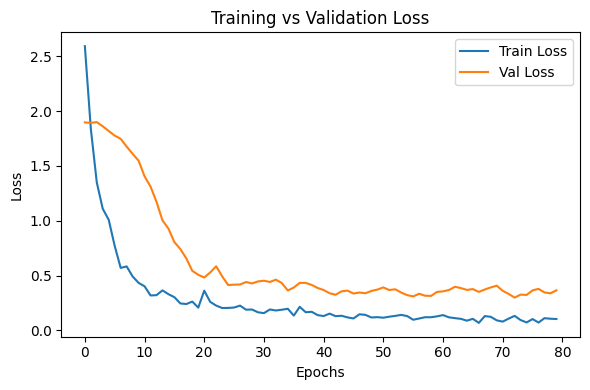

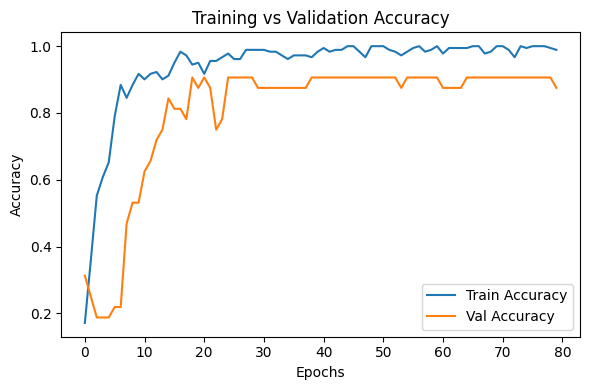

In [121]:
%matplotlib inline

train_loss = hist.history['loss']
val_loss   = hist.history['val_loss']
train_acc  = hist.history['accuracy']
val_acc    = hist.history['val_accuracy']

epochs = range(len(train_acc))

# Loss plot
plt.figure(figsize=(6,4))
plt.plot(epochs, train_loss, label='Train Loss')
plt.plot(epochs, val_loss, label='Val Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

# Accuracy plot
plt.figure(figsize=(6,4))
plt.plot(epochs, train_acc, label='Train Accuracy')
plt.plot(epochs, val_acc, label='Val Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()


Test Loss: 0.3652845621109009
Test Accuracy: 0.875
Test image shape: (1, 128, 128, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 607ms/step
Prediction probabilities: [[0.809434   0.10706171 0.0381415  0.01108098 0.02297059 0.00473943
  0.00657186]]
Predicted class: [0]
Actual class: 0


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 519ms/step


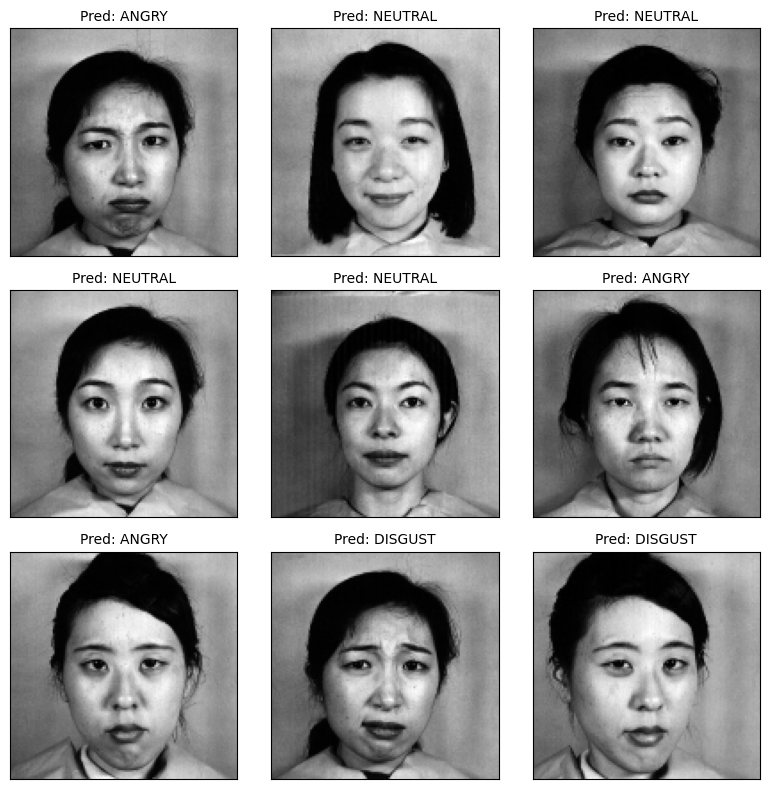

In [122]:
# Evaluating the model
score = model.evaluate(X_test, y_test, verbose=0)
print('Test Loss:', score[0])
print('Test Accuracy:', score[1])

# Predict single image
test_image = X_test[0:1]
print("Test image shape:", test_image.shape)

probs = model.predict(test_image)
pred_class = np.argmax(probs, axis=1)

print("Prediction probabilities:", probs)
print("Predicted class:", pred_class)
print("Actual class:", np.argmax(y_test[0:1]))

# Predict first 9 test images
probs_all = model.predict(X_test[:9])
res = np.argmax(probs_all, axis=1)

plt.figure(figsize=(8, 8))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_test[i].reshape(128,128), cmap='gray')
    plt.xticks([])
    plt.yticks([])
    plt.title('Pred: %s' % getLabel(res[i]), fontsize=10)

plt.tight_layout()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step


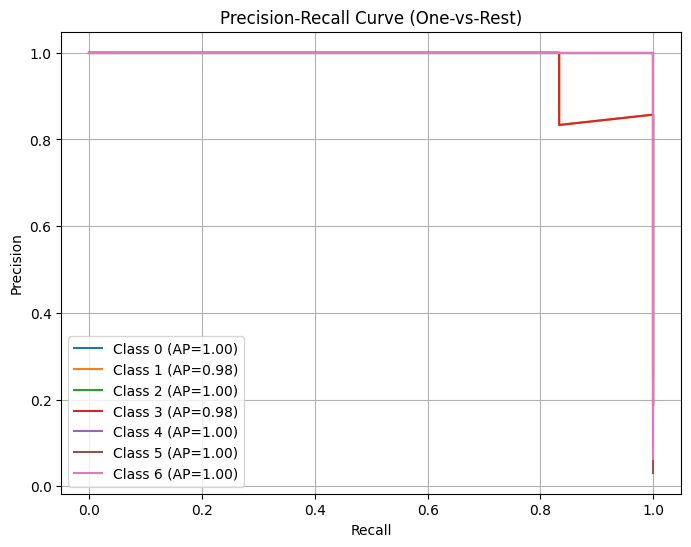

mAP (macro): 99.32 %


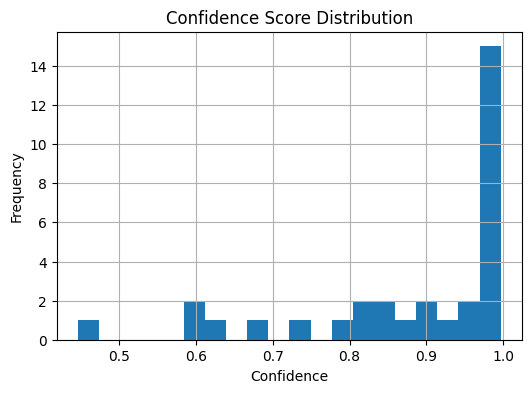

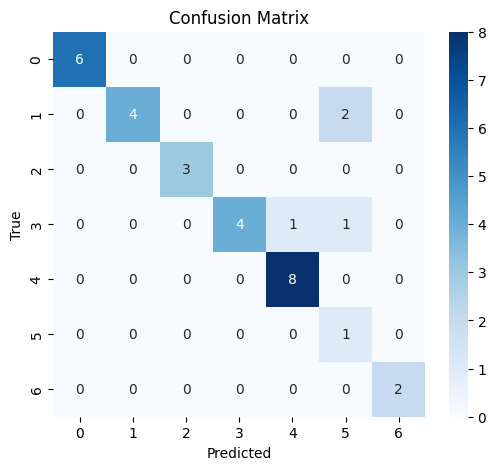

In [123]:
from sklearn.metrics import confusion_matrix, precision_recall_curve, average_precision_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# =========================
# 1. Predictions
# =========================
y_prob = model.predict(X_test)   # ✅ probabilities (IMPORTANT)
y_pred = np.argmax(y_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

num_classes = y_test.shape[1]

# =========================
# 2. Precision-Recall Curves (One-vs-Rest)
# =========================
plt.figure(figsize=(8,6))

for i in range(num_classes):
    precision, recall, _ = precision_recall_curve(y_test[:, i], y_prob[:, i])
    ap = average_precision_score(y_test[:, i], y_prob[:, i])

    plt.plot(recall, precision, label=f'Class {i} (AP={ap:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (One-vs-Rest)')
plt.legend()
plt.grid()
plt.show()

# =========================
# 3. mAP (Macro Average)
# =========================
map_score = average_precision_score(y_test, y_prob, average='macro')
print("mAP (macro):", round(map_score * 100, 2), "%")

# =========================
# 4. Confidence Distribution
# =========================
confidences = np.max(y_prob, axis=1)

plt.figure(figsize=(6,4))
plt.hist(confidences, bins=20)
plt.title("Confidence Score Distribution")
plt.xlabel("Confidence")
plt.ylabel("Frequency")
plt.grid()
plt.show()

# =========================
# 5. Confusion Matrix
# =========================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [124]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense, BatchNormalization, Activation
from tensorflow.keras.optimizers import Adam

def build_model_2(input_shape, num_classes, use_bn=False, use_dropout=True, lr=0.0001):

    model = Sequential()

    model.add(Conv2D(6, (5,5), padding='same', input_shape=input_shape))

    if use_bn:
        model.add(BatchNormalization())

    model.add(Activation('relu'))
    model.add(MaxPooling2D(pool_size=(2,2)))

    model.add(Conv2D(16, (5,5), padding='same'))

    if use_bn:
        model.add(BatchNormalization())

    model.add(Activation('relu'))
    model.add(MaxPooling2D(pool_size=(2,2)))

    model.add(Conv2D(120, (5,5)))

    if use_bn:
        model.add(BatchNormalization())

    model.add(Activation('relu'))

    if use_dropout:
        model.add(Dropout(0.25))

    model.add(Flatten())
    model.add(Dense(84))

    if use_bn:
        model.add(BatchNormalization())

    model.add(Activation('relu'))

    if use_dropout:
        model.add(Dropout(0.5))

    model.add(Dense(num_classes, activation='softmax'))

    model.compile(
        loss='categorical_crossentropy',
        optimizer=Adam(learning_rate=lr),
        metrics=['accuracy']
    )

    return model

In [125]:
# =========================
# ABLATION STUDY - MODEL 2
# =========================
import pandas as pd

# Ensure these exist
input_shape = X_train.shape[1:]
num_classes = y_train.shape[1]
model = build_model_2(input_shape, num_classes, use_bn=True, use_dropout=True, lr=0.0001)

results = []

def train_and_evaluate(model, name):
    history = model.fit(
        X_train, y_train,
        epochs=20,
        batch_size=32,
        validation_data=(X_test, y_test),
        verbose=0
    )

    acc = history.history['val_accuracy'][-1]
    results.append([name, acc])
    print(f"{name}: {acc*100:.2f}%")

# =========================
# 1. BASELINE
# =========================
model_baseline = build_model_2(input_shape, num_classes, use_bn=True, use_dropout=True, lr=0.0001)
train_and_evaluate(model_baseline, "Baseline")

# =========================
# 2. WITHOUT BATCH NORM
# =========================
model_no_bn = build_model_2(input_shape, num_classes, use_bn=False, use_dropout=True, lr=0.0001)
train_and_evaluate(model_no_bn, "No BatchNorm")

# =========================
# 3. WITHOUT DROPOUT
# =========================
model_no_dropout = build_model_2(input_shape, num_classes, use_bn=True, use_dropout=False, lr=0.0001)
train_and_evaluate(model_no_dropout, "No Dropout")

# =========================
# 4. HIGHER LR
# =========================
model_high_lr = build_model_2(input_shape, num_classes, use_bn=True, use_dropout=True, lr=0.001)
train_and_evaluate(model_high_lr, "High LR")

# =========================
# RESULTS TABLE
# =========================
df = pd.DataFrame(results, columns=["Experiment", "Validation Accuracy"])
print(df)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Baseline: 18.75%
No BatchNorm: 37.50%
No Dropout: 18.75%
High LR: 18.75%
     Experiment  Validation Accuracy
0      Baseline               0.1875
1  No BatchNorm               0.3750
2    No Dropout               0.1875
3       High LR               0.1875


Test image shape: (128, 128, 1)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 611ms/step
Prediction probabilities: [[0.13869628 0.13762698 0.13947748 0.15040632 0.14680225 0.14726068
  0.13972993]]
Predicted class index: [3]
Actual class index: 0


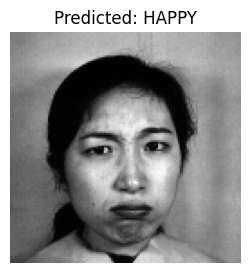

In [126]:
# Select a real test image (not label data)
test_img = X_test[0]
print("Test image shape:", test_img.shape)   # must be (128,128,1)

# Prepare image for prediction
testimg_data = test_img.reshape(1, 128, 128, 1)

# Predict
probs = model.predict(testimg_data)
pred_class = np.argmax(probs, axis=1)

print("Prediction probabilities:", probs)
print("Predicted class index:", pred_class)
print("Actual class index:", np.argmax(y_test[0]))

# Display image
plt.figure(figsize=(3,3))
plt.imshow(test_img.reshape(128,128), cmap='gray')
plt.title("Predicted: %s" % getLabel(pred_class[0]))
plt.axis('off')
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 511ms/step


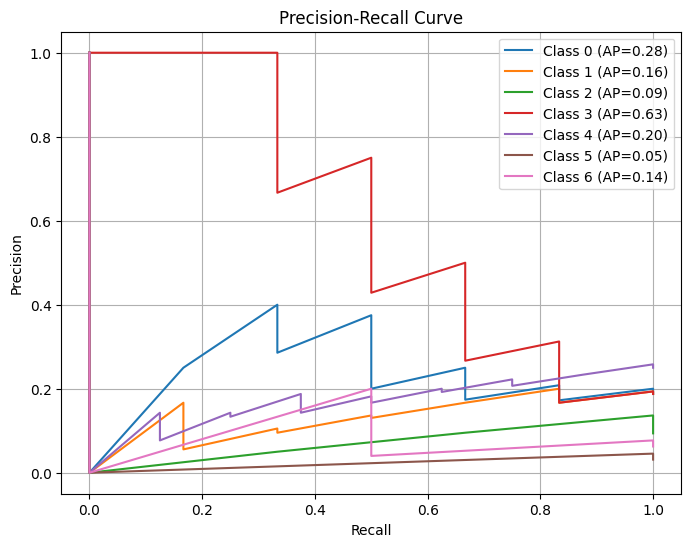

In [127]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.utils import to_categorical

# =========================
# Ensure correct format
# =========================
if len(y_test.shape) == 1:
    y_test = to_categorical(y_test, num_classes)

# =========================
# Predictions
# =========================
y_prob = model.predict(X_test)
y_pred = np.argmax(y_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

# =========================
# PR Curve
# =========================
plt.figure(figsize=(8,6))

for i in range(num_classes):
    precision, recall, _ = precision_recall_curve(y_test[:, i], y_prob[:, i])
    ap = average_precision_score(y_test[:, i], y_prob[:, i])

    plt.plot(recall, precision, label=f'Class {i} (AP={ap:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid()
plt.show()

In [128]:
from sklearn.metrics import classification_report

unique_labels = np.unique(y_true)

target_names = [getLabel(i) for i in unique_labels]

print(classification_report(
    y_true,
    y_pred,
    labels=unique_labels,
    target_names=target_names,
    zero_division=0
))


              precision    recall  f1-score   support

       ANGRY       0.00      0.00      0.00         6
     DISGUST       0.00      0.00      0.00         6
        FEAR       0.00      0.00      0.00         3
       HAPPY       0.19      1.00      0.32         6
     NEUTRAL       0.00      0.00      0.00         8
         SAD       0.00      0.00      0.00         1
    SURPRISE       0.00      0.00      0.00         2

    accuracy                           0.19        32
   macro avg       0.03      0.14      0.05        32
weighted avg       0.04      0.19      0.06        32



In [129]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_true, y_pred, average='weighted')
recall    = recall_score(y_true, y_pred, average='weighted')
f1        = f1_score(y_true, y_pred, average='weighted')

print("Overall Precision :", round(precision,4))
print("Overall Recall    :", round(recall,4))
print("Overall F1-score  :", round(f1,4))


Overall Precision : 0.0352
Overall Recall    : 0.1875
Overall F1-score  : 0.0592


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [130]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print("Final Test Accuracy:", round(test_acc*100,2), "%")


Final Test Accuracy: 18.75 %


In [131]:
true_label_name = "HAPPY"


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


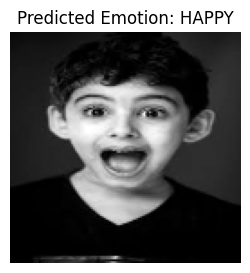

Prediction Probabilities: [[0.14024077 0.14227423 0.14419751 0.14726853 0.1459192  0.14187087
  0.13822891]]


In [132]:
# Path of your test image
test_image_path = "/content/drive/MyDrive/Facial_Expression/images.jfif"

# Read image in grayscale
img = cv2.imread(test_image_path, cv2.IMREAD_GRAYSCALE)

if img is None:
    print("Image not found. Check the path.")
else:
    # Resize to match training data
    img = cv2.resize(img, (128,128))
    img = img.astype("float32") / 255.0
    img = img.reshape(1,128,128,1)

    # Predict emotion
    probs = model.predict(img)
    pred_class = np.argmax(probs, axis=1)[0]

    # Display
    plt.figure(figsize=(3,3))
    plt.imshow(img.reshape(128,128), cmap='gray')
    plt.title("Predicted Emotion: " + getLabel(pred_class))
    plt.axis("off")
    plt.show()

    print("Prediction Probabilities:", probs)


In [133]:
# Map label name to index
true_label_index = expres_code.index(true_label_name.upper()[:2])

# Load and preprocess image
test_image_path = "/content/drive/MyDrive/Facial_Expression/images.jfif"
img = cv2.imread(test_image_path, cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (128,128))
img = img.astype("float32") / 255.0
img = img.reshape(1,128,128,1)

# Predict
probs = model.predict(img)
pred_class = np.argmax(probs, axis=1)[0]

# Accuracy for single image
accuracy = 1 if pred_class == true_label_index else 0

print("Predicted Emotion:", getLabel(pred_class))
print("True Emotion     :", true_label_name)
print("Single Image Accuracy:", accuracy)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Predicted Emotion: HAPPY
True Emotion     : HAPPY
Single Image Accuracy: 1


In [134]:
import pandas as pd

data_path = "/content/drive/MyDrive/Facial_Expression/ckextended.csv"
df = pd.read_csv(data_path)

print(df.head())
print("Total samples:", len(df))


   emotion                                             pixels     Usage
0        6  36 39 35 25 19 11 8 7 3 13 15 9 21 57 75 90 10...  Training
1        6  88 74 19 4 5 5 3 12 8 21 15 21 15 18 24 29 32 ...  Training
2        6  9 2 4 7 1 1 1 0 7 29 49 76 115 141 156 169 177...  Training
3        6  104 106 108 104 95 50 60 61 58 83 126 133 139 ...  Training
4        6  68 72 67 67 6 2 1 1 1 1 1 14 24 24 38 65 79 94...  Training
Total samples: 920


In [135]:
img_rows, img_cols = 48, 48
num_classes = 7

X_ck_raw, y_ck_raw = [], []

for i in range(len(df)):
    pixels = np.array(df.iloc[i]['pixels'].split(), dtype='float32')
    img = pixels.reshape(img_rows, img_cols)
    X_ck_raw.append(img)
    y_ck_raw.append(df.iloc[i]['emotion'])

X_ck_raw = np.array(X_ck_raw) / 255.0
X_ck_raw = X_ck_raw.reshape(-1, img_rows, img_cols, 1)
y_ck_raw = np.array(y_ck_raw)

print("CK+ Images:", X_ck_raw.shape)
print("CK+ Labels:", y_ck_raw.shape)


CK+ Images: (920, 48, 48, 1)
CK+ Labels: (920,)


In [136]:
# This cell is now redundant as t5VJgsvgAbGg handles the split for CK+ data.
# Keeping it commented out to avoid confusion and variable overwrites.
# num_classes = len(np.unique(y))
# print("Detected classes:", num_classes)

# from tensorflow.keras.utils import to_categorical
# from sklearn.model_selection import train_test_split

# Y = to_categorical(y, num_classes)

# X_train, X_test, y_train, y_test = train_test_split(
#     X, Y, test_size=0.15, random_state=42, stratify=y
# )


In [137]:
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

# num_classes for CK+ might differ if there are 8 emotions in total, needs to be len(np.unique(y_ck_raw))
# Assuming num_classes is 7 from earlier definition, adjust if necessary.
num_classes_ck = len(np.unique(y_ck_raw))

Y_ck = to_categorical(y_ck_raw, num_classes_ck)

X_train_ck, X_test_ck, y_train_ck, y_test_ck = train_test_split(
    X_ck_raw, Y_ck, test_size=0.15, random_state=42, stratify=y_ck_raw
)

print("X_train_ck shape:", X_train_ck.shape)
print("X_test_ck shape:", X_test_ck.shape)


X_train_ck shape: (782, 48, 48, 1)
X_test_ck shape: (138, 48, 48, 1)


In [138]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense, BatchNormalization, Activation
from tensorflow.keras.optimizers import Adam

def build_model_2_v2(input_shape, num_classes, use_bn=False, use_dropout=True, lr=0.0004):

    model = Sequential()

    # ===== Block 1 =====
    model.add(Conv2D(32,(3,3),padding='same', input_shape=input_shape))

    if use_bn:
        model.add(BatchNormalization())

    model.add(Activation('relu'))
    model.add(MaxPooling2D(2,2))

    if use_dropout:
        model.add(Dropout(0.25))

    # ===== Block 2 =====
    model.add(Conv2D(64,(3,3),padding='same'))

    if use_bn:
        model.add(BatchNormalization())

    model.add(Activation('relu'))
    model.add(MaxPooling2D(2,2))

    if use_dropout:
        model.add(Dropout(0.25))

    # ===== Block 3 =====
    model.add(Conv2D(128,(3,3),padding='same'))

    if use_bn:
        model.add(BatchNormalization())

    model.add(Activation('relu'))
    model.add(MaxPooling2D(2,2))

    if use_dropout:
        model.add(Dropout(0.30))

    # ===== Dense =====
    model.add(Flatten())
    model.add(Dense(256))

    if use_bn:
        model.add(BatchNormalization())

    model.add(Activation('relu'))

    if use_dropout:
        model.add(Dropout(0.50))

    model.add(Dense(num_classes, activation='softmax'))

    # Compile
    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [139]:
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)


In [140]:
# Fix input shape for CK+
input_shape = X_train_ck.shape[1:]
num_classes = y_train_ck.shape[1]

# Rebuild model
model = build_model_2(input_shape, num_classes, use_bn=True, use_dropout=True, lr=0.0001)

# Train
hist = model.fit(
    datagen.flow(X_train_ck, y_train_ck, batch_size=32),
    epochs=80,
    validation_data=(X_test_ck, y_test_ck),
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/80
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 212ms/step - accuracy: 0.1061 - loss: 2.8338 - val_accuracy: 0.0290 - val_loss: 2.0366
Epoch 2/80
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.1176 - loss: 2.7150 - val_accuracy: 0.0217 - val_loss: 2.0141
Epoch 3/80
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.1995 - loss: 2.4206 - val_accuracy: 0.0217 - val_loss: 2.0369
Epoch 4/80
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.2199 - loss: 2.3122 - val_accuracy: 0.0217 - val_loss: 2.0483
Epoch 5/80
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.2494 - loss: 2.2290 - val_accuracy: 0.0217 - val_loss: 2.0940
Epoch 6/80
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.3082 - loss: 2.0245 - val_accuracy: 0.0217 - val_loss: 2.0547
Epoch 7/80
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.3210 - loss: 1.9554 - val_accuracy: 0.0217 - val_loss: 2.0137
Epoch 8/80
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.3555 - loss: 1.8713 - val_accuracy: 0.0290 -

In [141]:
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    precision_score, recall_score, f1_score,
    cohen_kappa_score, matthews_corrcoef, roc_auc_score,
    precision_recall_curve, average_precision_score
)

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.utils import to_categorical


def evaluate_model(model, X_test, y_test, class_names, dataset_name):

    print(f"\n================ {dataset_name} Evaluation Metrics ================\n")

    # =========================
    # Ensure one-hot encoding
    # =========================
    if len(y_test.shape) == 1:
        y_test = to_categorical(y_test)

    num_classes = y_test.shape[1]

    # =========================
    # Predictions
    # =========================
    y_pred_prob = model.predict(X_test)
    y_pred = np.argmax(y_pred_prob, axis=1)
    y_true = np.argmax(y_test, axis=1)

    # =========================
    # Precision-Recall Curves
    # =========================
    plt.figure(figsize=(8,6))

    ap_scores = []

    for i in range(num_classes):
        precision, recall, _ = precision_recall_curve(y_test[:, i], y_pred_prob[:, i])
        ap = average_precision_score(y_test[:, i], y_pred_prob[:, i])
        ap_scores.append(ap)

        plt.plot(recall, precision, label=f'{class_names[i]} (AP={ap:.2f})')

    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'{dataset_name} Precision-Recall Curve')
    plt.legend()
    plt.grid()
    plt.show()

    # =========================
    # mAP
    # =========================
    map_score = np.mean(ap_scores)
    print(f"mAP (macro)           : {map_score*100:.2f}%")

    # =========================
    # Standard Metrics
    # =========================
    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    kappa = cohen_kappa_score(y_true, y_pred)
    mcc = matthews_corrcoef(y_true, y_pred)

    try:
        roc_auc = roc_auc_score(y_test, y_pred_prob, multi_class='ovr')
    except:
        roc_auc = "Not Computed"

    print(f"Accuracy              : {acc*100:.2f}%")
    print(f"Precision (Weighted)  : {precision:.4f}")
    print(f"Recall (Weighted)     : {recall:.4f}")
    print(f"F1-Score (Weighted)   : {f1:.4f}")
    print(f"Cohen Kappa Score     : {kappa:.4f}")
    print(f"Matthews Corrcoef     : {mcc:.4f}")
    print(f"ROC-AUC Score         : {roc_auc}")

    # =========================
    # Classification Report
    # =========================
    print("\n--- Classification Report ---\n")
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

    # =========================
    # Confusion Matrix
    # =========================
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names)

    plt.title(f"{dataset_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    return map_score

In [142]:
import pandas as pd

data_path = "/content/drive/MyDrive/Facial_Expression/fer2013.csv"
df = pd.read_csv(data_path)

print(df.head())
print("Total samples:", len(df))


   emotion                                             pixels     Usage
0        0  70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...  Training
1        0  151 150 147 155 148 133 111 140 170 174 182 15...  Training
2        2  231 212 156 164 174 138 161 173 182 200 106 38...  Training
3        4  24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...  Training
4        6  4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...  Training
Total samples: 35887


In [143]:
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# Convert pixels to image
img_array = df.pixels.apply(
    lambda x: np.array(x.split(' '), dtype='float32').reshape(48,48,1)
)
img_array = np.stack(img_array, axis=0)

# Labels (ONLY ONCE)
labels = df.emotion.values

# Split
X_train_fer, X_test_fer, y_train_fer, y_test_fer = train_test_split(
    img_array, labels, test_size=0.1, random_state=42
)

# Normalize
X_train_fer = X_train_fer / 255.0
X_test_fer  = X_test_fer / 255.0

# One-hot encoding (ONLY ONCE)
num_classes = len(np.unique(labels))
y_train_fer = to_categorical(y_train_fer, num_classes)
y_test_fer  = to_categorical(y_test_fer, num_classes)

# CHECK
print("X_train:", X_train_fer.shape)
print("y_train:", y_train_fer.shape)

X_train: (32298, 48, 48, 1)
y_train: (32298, 7)


In [144]:
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

Y_fer = to_categorical(y_fer_raw, num_classes)

X_train_fer, X_test_fer, y_train_fer, y_test_fer = train_test_split(
    X_fer_raw, Y_fer, test_size=0.15, random_state=42, stratify=y_fer_raw
)

print("X_train_fer shape:", X_train_fer.shape)
print("X_test_fer shape:", X_test_fer.shape)


X_train_fer shape: (30503, 48, 48, 1)
X_test_fer shape: (5384, 48, 48, 1)


In [145]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense, BatchNormalization, Activation
from tensorflow.keras.optimizers import Adam

def build_model_2_final(input_shape, num_classes, use_bn=False, use_dropout=True, lr=0.0005):

    model = Sequential()

    # ===== Block 1 =====
    model.add(Conv2D(32,(3,3),padding='same', input_shape=input_shape))

    if use_bn:
        model.add(BatchNormalization())

    model.add(Activation('relu'))
    model.add(MaxPooling2D(2,2))

    if use_dropout:
        model.add(Dropout(0.25))

    # ===== Block 2 =====
    model.add(Conv2D(64,(3,3),padding='same'))

    if use_bn:
        model.add(BatchNormalization())

    model.add(Activation('relu'))
    model.add(MaxPooling2D(2,2))

    if use_dropout:
        model.add(Dropout(0.25))

    # ===== Block 3 =====
    model.add(Conv2D(128,(3,3),padding='same'))

    if use_bn:
        model.add(BatchNormalization())

    model.add(Activation('relu'))
    model.add(MaxPooling2D(2,2))

    if use_dropout:
        model.add(Dropout(0.25))

    # ===== Dense =====
    model.add(Flatten())
    model.add(Dense(256))

    if use_bn:
        model.add(BatchNormalization())

    model.add(Activation('relu'))

    if use_dropout:
        model.add(Dropout(0.5))

    model.add(Dense(num_classes, activation='softmax'))

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [146]:
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)


In [147]:
from tensorflow.keras.utils import to_categorical

num_classes = len(np.unique(y_train_fer))

y_train_fer = to_categorical(y_train_fer, num_classes)
y_test_fer  = to_categorical(y_test_fer, num_classes)

In [148]:
print("X_train_fer:", X_train_fer.shape)
print("y_train_fer:", y_train_fer.shape)
print("dtype:", y_train_fer.dtype)

X_train_fer: (30503, 48, 48, 1)
y_train_fer: (30503, 7, 2)
dtype: float64


In [149]:
X_train_fer = np.array(X_train_fer, dtype='float32')
y_train_fer = np.array(y_train_fer)

In [150]:
print(type(X_train_fer))
print(type(y_train_fer))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [153]:
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# Convert pixels → image
img_array = df.pixels.apply(
    lambda x: np.array(x.split(' '), dtype='float32').reshape(48,48,1)
)
img_array = np.stack(img_array, axis=0)

# Labels (ONLY ONCE)
labels = df.emotion.values

# Split
X_train_fer, X_test_fer, y_train_fer, y_test_fer = train_test_split(
    img_array, labels, test_size=0.1, random_state=42
)

# Normalize
X_train_fer = X_train_fer / 255.0
X_test_fer  = X_test_fer / 255.0

# One-hot (ONLY ONCE)
num_classes = len(np.unique(labels))
y_train_fer = to_categorical(y_train_fer, num_classes)
y_test_fer  = to_categorical(y_test_fer, num_classes)

# CHECK (must match)
print("X_train:", X_train_fer.shape)
print("y_train:", y_train_fer.shape)

X_train: (32298, 48, 48, 1)
y_train: (32298, 7)


In [154]:
batch = next(datagen.flow(X_train_fer, y_train_fer, batch_size=64))

print("Batch X:", batch[0].shape)
print("Batch y:", batch[1].shape)

Batch X: (64, 48, 48, 1)
Batch y: (64, 7)


In [155]:
input_shape = X_train_fer.shape[1:]
num_classes = y_train_fer.shape[1]

model = build_model_2(input_shape, num_classes, use_bn=True, use_dropout=True, lr=0.0001)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [156]:
hist = model.fit(
    datagen.flow(X_train_fer, y_train_fer, batch_size=64),
    epochs=50,
    validation_data=(X_test_fer, y_test_fer),
    verbose=1
)

Epoch 1/50
505/505 ━━━━━━━━━━━━━━━━━━━━ 32s 47ms/step - accuracy: 0.2321 - loss: 2.1238 - val_accuracy: 0.3516 - val_loss: 1.6807
Epoch 2/50
505/505 ━━━━━━━━━━━━━━━━━━━━ 16s 33ms/step - accuracy: 0.2853 - loss: 1.8662 - val_accuracy: 0.3801 - val_loss: 1.6089
Epoch 3/50
505/505 ━━━━━━━━━━━━━━━━━━━━ 17s 34ms/step - accuracy: 0.3107 - loss: 1.7811 - val_accuracy: 0.4101 - val_loss: 1.5272
Epoch 4/50
505/505 ━━━━━━━━━━━━━━━━━━━━ 19s 38ms/step - accuracy: 0.3349 - loss: 1.7139 - val_accuracy: 0.4238 - val_loss: 1.4963
Epoch 5/50
505/505 ━━━━━━━━━━━━━━━━━━━━ 17s 33ms/step - accuracy: 0.3532 - loss: 1.6681 - val_accuracy: 0.4508 - val_loss: 1.4663
Epoch 6/50
505/505 ━━━━━━━━━━━━━━━━━━━━ 17s 34ms/step - accuracy: 0.3644 - loss: 1.6356 - val_accuracy: 0.4603 - val_loss: 1.4315
Epoch 7/50
505/505 ━━━━━━━━━━━━━━━━━━━━ 17s 33ms/step - accuracy: 0.3814 - loss: 1.6028 - val_accuracy: 0.4411 - val_loss: 1.4303
Epoch 8/50
505/505 ━━━━━━━━━━━━━━━━━━━━ 17s 33ms/step - accuracy: 0.3897 - loss: 1.5676 - 

In [157]:
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    precision_score, recall_score, f1_score,
    cohen_kappa_score, matthews_corrcoef, roc_auc_score
)
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


In [158]:
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    precision_score, recall_score, f1_score,
    cohen_kappa_score, matthews_corrcoef,
    precision_recall_curve, average_precision_score
)

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.utils import to_categorical


def evaluate_model(model, X_test, y_test, class_names, dataset_name):

    print(f"\n================ {dataset_name} Evaluation Metrics =================\n")

    # =========================
    # Ensure one-hot encoding
    # =========================
    if len(y_test.shape) == 1:
        y_test = to_categorical(y_test)

    num_classes = y_test.shape[1]

    # =========================
    # Predictions
    # =========================
    y_pred_prob = model.predict(X_test)
    y_pred = np.argmax(y_pred_prob, axis=1)
    y_true = np.argmax(y_test, axis=1)

    # =========================
    # Precision-Recall + AP
    # =========================
    plt.figure(figsize=(8,6))
    ap_scores = []

    for i in range(num_classes):
        precision, recall, _ = precision_recall_curve(y_test[:, i], y_pred_prob[:, i])
        ap = average_precision_score(y_test[:, i], y_pred_prob[:, i])
        ap_scores.append(ap)

        plt.plot(recall, precision, label=f'{class_names[i]} (AP={ap:.2f})')

    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'{dataset_name} Precision-Recall Curve')
    plt.legend()
    plt.grid()
    plt.show()

    # =========================
    # TRUE mAP (NOT ROC-AUC)
    # =========================
    mean_average_precision = np.mean(ap_scores)
    print(f"Mean Average Precision (mAP): {mean_average_precision*100:.2f}%")

    # =========================
    # Standard Metrics
    # =========================
    acc = accuracy_score(y_true, y_pred)
    precision_weighted = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall_weighted = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1_weighted = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    precision_unweighted = precision_score(y_true, y_pred, average='macro', zero_division=0)
    recall_unweighted = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1_unweighted = f1_score(y_true, y_pred, average='macro', zero_division=0)

    kappa = cohen_kappa_score(y_true, y_pred)
    mcc = matthews_corrcoef(y_true, y_pred)

    print(f"Accuracy              : {acc*100:.2f}%")
    print(f"Precision (Weighted)  : {precision_weighted:.4f}")
    print(f"Recall (Weighted)     : {recall_weighted:.4f}")
    print(f"F1-Score (Weighted)   : {f1_weighted:.4f}")
    print(f"Precision (Unweighted): {precision_unweighted:.4f}")
    print(f"Recall (Unweighted)   : {recall_unweighted:.4f}")
    print(f"F1-Score (Unweighted) : {f1_unweighted:.4f}")
    print(f"Cohen Kappa Score     : {kappa:.4f}")
    print(f"Matthews Corrcoef     : {mcc:.4f}")

    # =========================
    # Classification Report
    # =========================
    print("\n--- Classification Report ---\n")
    print(classification_report(
        y_true, y_pred,
        labels=np.arange(len(class_names)),
        target_names=class_names,
        zero_division=0
    ))

    # =========================
    # Confusion Matrix
    # =========================
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names)

    plt.title(f"{dataset_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    return {
        'accuracy': acc,
        'precision_weighted': precision_weighted,
        'recall_weighted': recall_weighted,
        'f1_weighted': f1_weighted,
        'precision_unweighted': precision_unweighted,
        'recall_unweighted': recall_unweighted,
        'f1_unweighted': f1_unweighted,
        'kappa': kappa,
        'mcc': mcc,
        'mean_average_precision': mean_average_precision
    }

In [159]:
input_shape = X_train_fer.shape[1:]
num_classes = y_train_fer.shape[1]

model = build_model_2(input_shape, num_classes, use_bn=True, use_dropout=True, lr=0.0001)

In [161]:
import pandas as pd

results = []

def train_and_evaluate(model, name):
    history = model.fit(
        X_train_fer, y_train_fer,
        epochs=20,
        batch_size=32,
        validation_data=(X_test_fer, y_test_fer),
        verbose=0
    )

    acc = history.history['val_accuracy'][-1]
    results.append([name, acc])
    print(f"{name}: {acc*100:.2f}%")

# Define correct shape
input_shape = X_train_fer.shape[1:]
num_classes = y_train_fer.shape[1]

# Baseline
model_baseline = build_model_2(input_shape, num_classes, use_bn=True, use_dropout=True, lr=0.0001)
train_and_evaluate(model_baseline, "Baseline")

# No BN
model_no_bn = build_model_2(input_shape, num_classes, use_bn=False, use_dropout=True, lr=0.0001)
train_and_evaluate(model_no_bn, "No BatchNorm")

# No Dropout
model_no_dropout = build_model_2(input_shape, num_classes, use_bn=True, use_dropout=False, lr=0.0001)
train_and_evaluate(model_no_dropout, "No Dropout")

# High LR
model_high_lr = build_model_2(input_shape, num_classes, use_bn=True, use_dropout=True, lr=0.001)
train_and_evaluate(model_high_lr, "High LR")

# Results
df = pd.DataFrame(results, columns=["Experiment", "Validation Accuracy"])
print(df)

Baseline: 55.25%
No BatchNorm: 52.83%
No Dropout: 49.35%
High LR: 56.42%
     Experiment  Validation Accuracy
0      Baseline             0.552522
1  No BatchNorm             0.528281
2    No Dropout             0.493452
3       High LR             0.564224



================ FER2013 Dataset Evaluation Metrics =================

113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


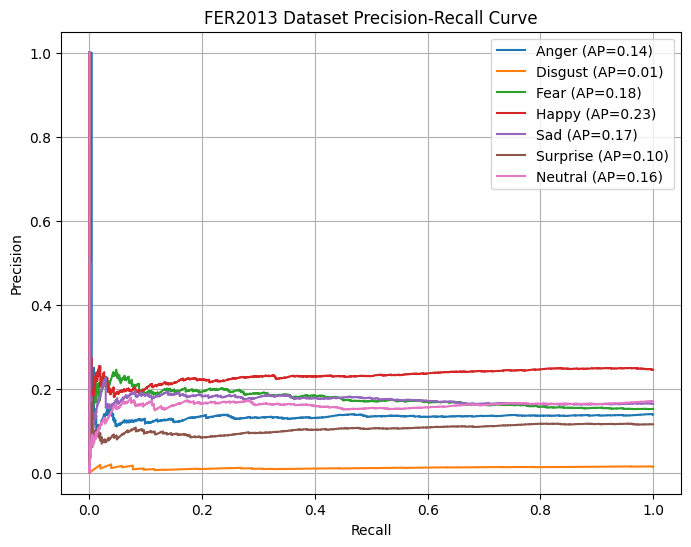

Mean Average Precision (mAP): 14.25%
Accuracy              : 24.52%
Precision (Weighted)  : 0.2231
Recall (Weighted)     : 0.2452
F1-Score (Weighted)   : 0.1026
Precision (Unweighted): 0.1980
Recall (Unweighted)   : 0.1435
F1-Score (Unweighted) : 0.0612
Cohen Kappa Score     : 0.0017
Matthews Corrcoef     : 0.0070

--- Classification Report ---

              precision    recall  f1-score   support

       Anger       1.00      0.00      0.00       498
     Disgust       0.00      0.00      0.00        52
        Fear       0.00      0.00      0.00       545
       Happy       0.25      0.99      0.40       881
         Sad       0.00      0.00      0.00       588
    Surprise       0.00      0.00      0.00       414
     Neutral       0.14      0.02      0.03       611

    accuracy                           0.25      3589
   macro avg       0.20      0.14      0.06      3589
weighted avg       0.22      0.25      0.10      3589



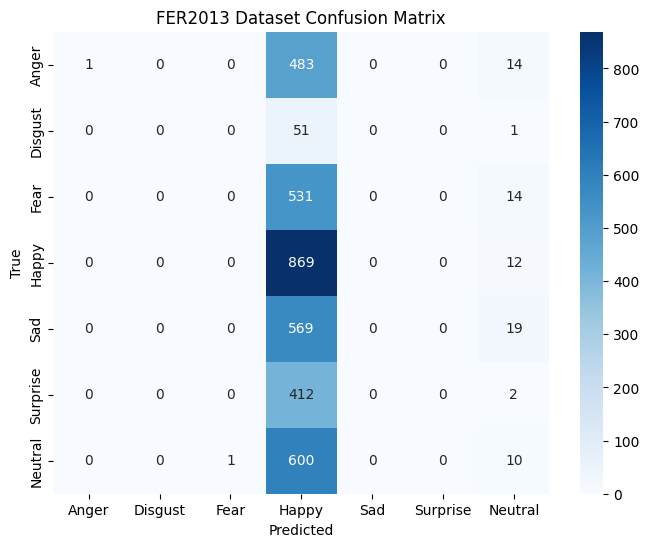

{'accuracy': 0.24519364725550294,
 'precision_weighted': 0.2230892644194986,
 'recall_weighted': 0.24519364725550294,
 'f1_weighted': 0.10259105416587774,
 'precision_unweighted': 0.19801643749012168,
 'recall_unweighted': 0.1435362512688941,
 'f1_unweighted': 0.06123571579303424,
 'kappa': np.float64(0.0017013768420331976),
 'mcc': np.float64(0.007032271947957483),
 'mean_average_precision': np.float64(0.14250605767049238)}

In [162]:
fer_classes = ['Anger','Disgust','Fear','Happy','Sad','Surprise','Neutral']
evaluate_model(model, X_test_fer, y_test_fer, fer_classes, "FER2013 Dataset")

### Training and Validation Graphs for FER2013 Dataset

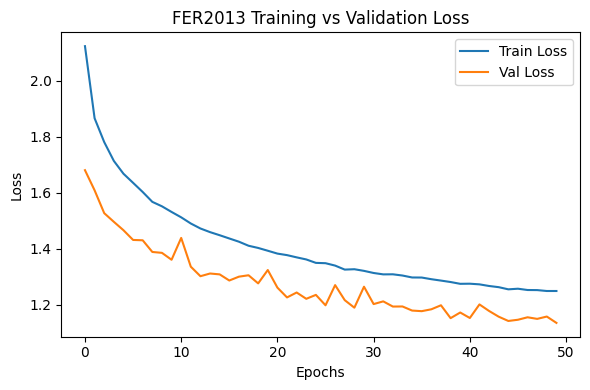

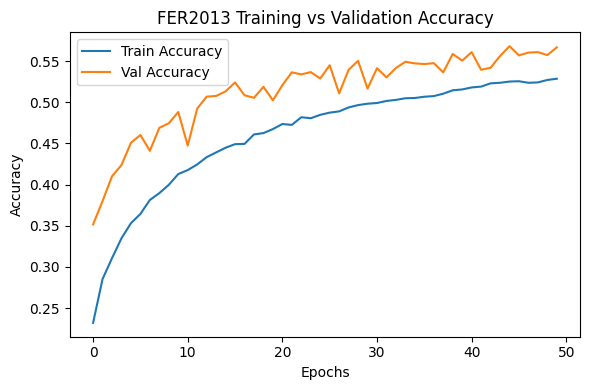

In [163]:
train_loss_fer = hist.history['loss']
val_loss_fer   = hist.history['val_loss']
train_acc_fer  = hist.history['accuracy']
val_acc_fer    = hist.history['val_accuracy']

epochs_fer = range(len(train_acc_fer))

# Loss plot
plt.figure(figsize=(6,4))
plt.plot(epochs_fer, train_loss_fer, label='Train Loss')
plt.plot(epochs_fer, val_loss_fer, label='Val Loss')
plt.title('FER2013 Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

# Accuracy plot
plt.figure(figsize=(6,4))
plt.plot(epochs_fer, train_acc_fer, label='Train Accuracy')
plt.plot(epochs_fer, val_acc_fer, label='Val Accuracy')
plt.title('FER2013 Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

In [164]:
input_shape = img_data.shape[1:]   # (128,128,1)

model_jeffe = Sequential()

model_jeffe.add(Conv2D(6, (5,5), padding='same', activation='relu', input_shape=input_shape))
model_jeffe.add(MaxPooling2D(pool_size=(2,2)))

model_jeffe.add(Conv2D(16, (5,5), padding='same', activation='relu'))
model_jeffe.add(MaxPooling2D(pool_size=(2,2)))

model_jeffe.add(Conv2D(120, (5,5), activation='relu'))
model_jeffe.add(Dropout(0.25))

model_jeffe.add(Flatten())
model_jeffe.add(Dense(84, activation='relu'))
model_jeffe.add(Dropout(0.5))
model_jeffe.add(Dense(num_classes, activation='softmax'))

model_jeffe.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.0001),
    metrics=['accuracy']
)

model_jeffe.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_26"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_78 (Conv2D)              │ (None, 128, 128, 6)    │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_52 (MaxPooling2D) │ (None, 64, 64, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_79 (Conv2D)              │ (None, 64, 64, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_53 (MaxPooling2D) │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_80 (Conv2D)              │ (None, 28, 28, 120)    │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_44 (Dropout)            │ (None, 28, 28, 120)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_26 (Flatten)            │ (None, 94080)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (None, 84)             │     7,902,804 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_45 (Dropout)            │ (None, 84)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 7)              │           595 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,954,091 (30.34 MB)

 Trainable params: 7,954,091 (30.34 MB)

 Non-trainable params: 0 (0.00 B)

In [165]:
hist_jeffe = model_jeffe.fit(
    X_train, y_train,
    batch_size=7,
    epochs=80,
    verbose=1,
    validation_data=(X_test, y_test),
    callbacks=callbacks_list
)

Epoch 1/80
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.1595 - loss: 1.9589
Epoch 1: val_loss did not improve from 0.29861
26/26 ━━━━━━━━━━━━━━━━━━━━ 10s 180ms/step - accuracy: 0.1381 - loss: 1.9651 - val_accuracy: 0.0312 - val_loss: 1.9682
Epoch 2/80
19/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2704 - loss: 1.9208
Epoch 2: val_loss did not improve from 0.29861
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2155 - loss: 1.9290 - val_accuracy: 0.0312 - val_loss: 1.9740
Epoch 3/80
19/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3075 - loss: 1.9119
Epoch 3: val_loss did not improve from 0.29861
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2431 - loss: 1.9124 - val_accuracy: 0.0625 - val_loss: 1.9591
Epoch 4/80
20/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2442 - loss: 1.8772
Epoch 4: val_loss did not improve from 0.29861
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2320 - loss: 1.8886 - val_accuracy: 0.0938 - val_loss: 1.9390
Epoch 5/80


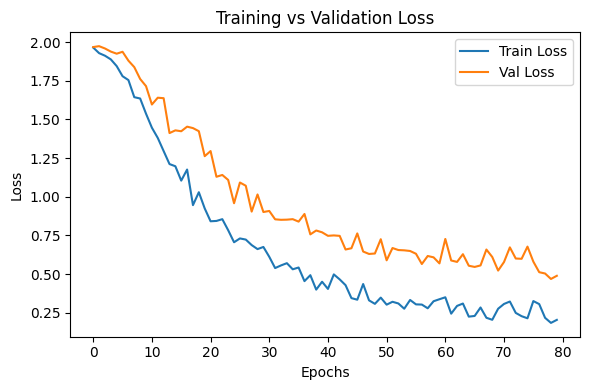

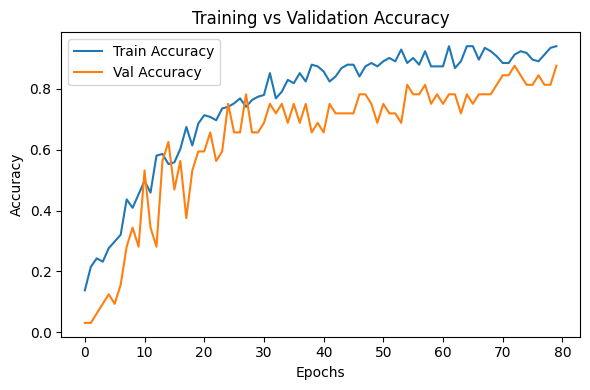

In [166]:
%matplotlib inline

train_loss = hist_jeffe.history['loss']
val_loss   = hist_jeffe.history['val_loss']
train_acc  = hist_jeffe.history['accuracy']
val_acc    = hist_jeffe.history['val_accuracy']

epochs = range(len(train_acc))

# Loss plot
plt.figure(figsize=(6,4))
plt.plot(epochs, train_loss, label='Train Loss')
plt.plot(epochs, val_loss, label='Val Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

# Accuracy plot
plt.figure(figsize=(6,4))
plt.plot(epochs, train_acc, label='Train Accuracy')
plt.plot(epochs, val_acc, label='Val Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

In [167]:
model_ck = Sequential()

model_ck.add(Conv2D(32,(3,3),padding='same',activation='relu',input_shape=(48,48,1)))
model_ck.add(MaxPooling2D(2,2))
model_ck.add(Dropout(0.25))

model_ck.add(Conv2D(64,(3,3),padding='same',activation='relu'))
model_ck.add(MaxPooling2D(2,2))
model_ck.add(Dropout(0.25))

model_ck.add(Conv2D(128,(3,3),padding='same',activation='relu'))
model_ck.add(MaxPooling2D(2,2))
model_ck.add(Dropout(0.30))

model_ck.add(Flatten())
model_ck.add(Dense(256,activation='relu'))
model_ck.add(Dropout(0.50))
model_ck.add(Dense(num_classes_ck,activation='softmax')) # Changed to num_classes_ck

model_ck.compile(
    optimizer=Adam(learning_rate=0.0004),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_ck.summary()

Model: "sequential_27"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_81 (Conv2D)              │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_54 (MaxPooling2D) │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_46 (Dropout)            │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_82 (Conv2D)              │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_55 (MaxPooling2D) │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_47 (Dropout)            │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_83 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_56 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_48 (Dropout)            │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_27 (Flatten)            │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_54 (Dense)                │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_49 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_55 (Dense)                │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,274,632 (4.86 MB)

 Trainable params: 1,274,632 (4.86 MB)

 Non-trainable params: 0 (0.00 B)

In [168]:
hist_ck = model_ck.fit(
    datagen.flow(X_train_ck, y_train_ck, batch_size=32),
    epochs=80,
    validation_data=(X_test_ck, y_test_ck),
    verbose=1
)

Epoch 1/80
25/25 ━━━━━━━━━━━━━━━━━━━━ 15s 336ms/step - accuracy: 0.6189 - loss: 1.4454 - val_accuracy: 0.6449 - val_loss: 1.5735
Epoch 2/80
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6445 - loss: 1.3895 - val_accuracy: 0.6449 - val_loss: 1.4816
Epoch 3/80
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6445 - loss: 1.3843 - val_accuracy: 0.6449 - val_loss: 1.5151
Epoch 4/80
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6445 - loss: 1.3610 - val_accuracy: 0.6449 - val_loss: 1.4067
Epoch 5/80
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.6445 - loss: 1.3486 - val_accuracy: 0.6449 - val_loss: 1.4661
Epoch 6/80
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6445 - loss: 1.3480 - val_accuracy: 0.6449 - val_loss: 1.4930
Epoch 7/80
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.6445 - loss: 1.3218 - val_accuracy: 0.6449 - val_loss: 1.4464
Epoch 8/80
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6445 - loss: 1.3427 - val_accuracy: 0.6449 -

In [169]:
hist_ck = model_ck.fit(
    datagen.flow(X_train_ck, y_train_ck, batch_size=32),
    epochs=80,
    validation_data=(X_test_ck, y_test_ck),
    verbose=1
)

Epoch 1/80
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.8286 - loss: 0.5339 - val_accuracy: 0.8623 - val_loss: 0.4542
Epoch 2/80
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8286 - loss: 0.5412 - val_accuracy: 0.8841 - val_loss: 0.3932
Epoch 3/80
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.8312 - loss: 0.5440 - val_accuracy: 0.8841 - val_loss: 0.4223
Epoch 4/80
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8427 - loss: 0.4890 - val_accuracy: 0.8913 - val_loss: 0.3945
Epoch 5/80
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8274 - loss: 0.5200 - val_accuracy: 0.8841 - val_loss: 0.4069
Epoch 6/80
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.8427 - loss: 0.4859 - val_accuracy: 0.8913 - val_loss: 0.3854
Epoch 7/80
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.8261 - loss: 0.5181 - val_accuracy: 0.8841 - val_loss: 0.3655
Epoch 8/80
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8299 - loss: 0.5375 - val_accuracy: 0.8986 - v

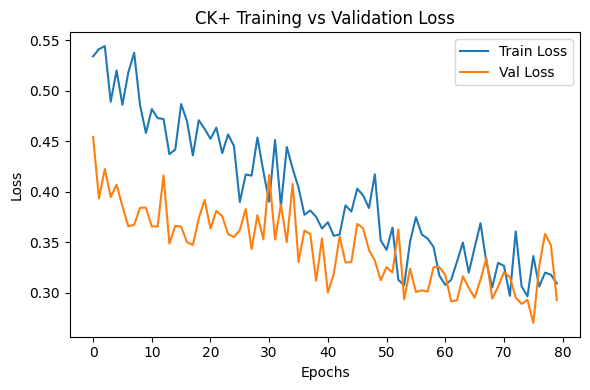

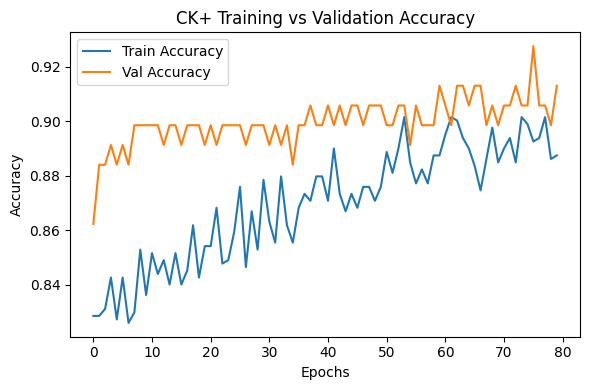

In [170]:
train_loss_ck = hist_ck.history['loss']
val_loss_ck   = hist_ck.history['val_loss']
train_acc_ck  = hist_ck.history['accuracy']
val_acc_ck    = hist_ck.history['val_accuracy']

epochs_ck = range(len(train_acc_ck))

# Loss plot
plt.figure(figsize=(6,4))
plt.plot(epochs_ck, train_loss_ck, label='Train Loss')
plt.plot(epochs_ck, val_loss_ck, label='Val Loss')
plt.title('CK+ Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

# Accuracy plot
plt.figure(figsize=(6,4))
plt.plot(epochs_ck, train_acc_ck, label='Train Accuracy')
plt.plot(epochs_ck, val_acc_ck, label='Val Accuracy')
plt.title('CK+ Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

In [171]:
jeffe_emotion_labels = ['ANGRY', 'DISGUST', 'FEAR', 'HAPPY', 'NEUTRAL', 'SAD', 'SURPRISE']
print("Jeffe emotion labels defined:", jeffe_emotion_labels)

Jeffe emotion labels defined: ['ANGRY', 'DISGUST', 'FEAR', 'HAPPY', 'NEUTRAL', 'SAD', 'SURPRISE']


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Epoch 1: val_loss improved from None to 1.93373, saving model to Best-weights-my_model-001-1.9337-0.2188.keras

Epoch 1: finished saving model to Best-weights-my_model-001-1.9337-0.2188.keras

Epoch 2: val_loss improved from 1.93373 to 1.78856, saving model to Best-weights-my_model-002-1.7886-0.3438.keras

Epoch 2: finished saving model to Best-weights-my_model-002-1.7886-0.3438.keras

Epoch 3: val_loss improved from 1.78856 to 1.50412, saving model to Best-weights-my_model-003-1.5041-0.4375.keras

Epoch 3: finished saving model to Best-weights-my_model-003-1.5041-0.4375.keras

Epoch 4: val_loss improved from 1.50412 to 1.19603, saving model to Best-weights-my_model-004-1.1960-0.5938.keras

Epoch 4: finished saving model to Best-weights-my_model-004-1.1960-0.5938.keras

Epoch 5: val_loss improved from 1.19603 to 0.96784, saving model to Best-weights-my_model

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


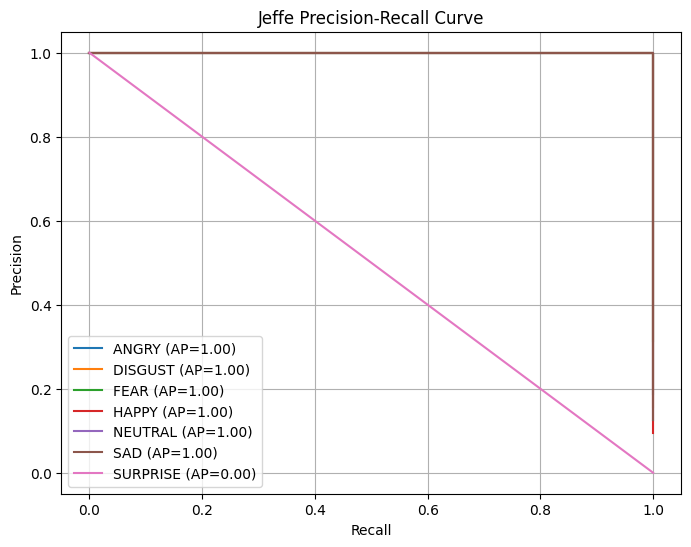

Mean Average Precision (mAP): 85.71%
Accuracy              : 96.88%
Precision (Weighted)  : 0.9732
Recall (Weighted)     : 0.9688
F1-Score (Weighted)   : 0.9682
Precision (Unweighted): 0.9762
Recall (Unweighted)   : 0.9667
F1-Score (Unweighted) : 0.9687
Cohen Kappa Score     : 0.9610
Matthews Corrcoef     : 0.9622

--- Classification Report ---

              precision    recall  f1-score   support

       ANGRY       0.86      1.00      0.92         6
     DISGUST       1.00      0.80      0.89         5
        FEAR       1.00      1.00      1.00        10
       HAPPY       1.00      1.00      1.00         3
     NEUTRAL       1.00      1.00      1.00         4
         SAD       1.00      1.00      1.00         4
    SURPRISE       0.00      0.00      0.00         0

    accuracy                           0.97        32
   macro avg       0.84      0.83      0.83        32
weighted avg       0.97      0.97      0.97        32



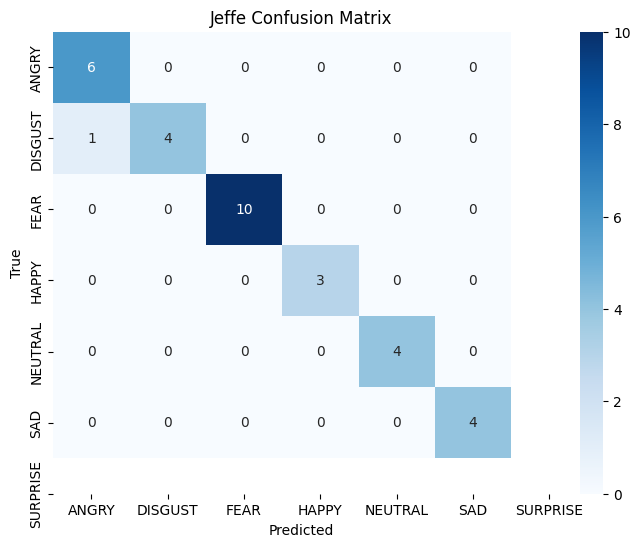

In [172]:
from google.colab import drive
drive.mount('/content/drive')

from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    precision_score, recall_score, f1_score,
    cohen_kappa_score, matthews_corrcoef, roc_auc_score
)
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.callbacks import CSVLogger, ModelCheckpoint
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import os, cv2
from sklearn.utils import shuffle

# Re-initialize Jeffe dataset variables and split data
data_path = "/content/drive/MyDrive/Facial_Expression/Jeffe"

img_rows = 128
img_cols = 128
num_channel = 1

img_data_list = []
labels = []

for img_name in os.listdir(data_path):

    img_path = os.path.join(data_path, img_name)

    if not os.path.isfile(img_path):
        continue

    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        continue

    img = cv2.resize(img, (img_rows, img_cols))
    img_data_list.append(img)

    expres_code = ['AN','DI','FE','HA','NE','SA','SU']


    label_code = img_name[3:5]
    labels.append(expres_code.index(label_code))

img_data = np.array(img_data_list, dtype='float32') / 255.0
img_data = img_data.reshape(-1, img_rows, img_cols, 1)

num_classes = 7
num_of_samples = img_data.shape[0]
labels = np.ones((num_of_samples,),dtype='int64')

labels[0:29]=0 #30
labels[30:59]=1 #29
labels[60:92]=2 #32
labels[93:124]=3 #31
labels[125:155]=4 #30
labels[156:187]=5 #31
labels[188:]=6 #30

Y = to_categorical(labels, num_classes)
x,y = shuffle(img_data,Y, random_state=2)
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.15, random_state=2)

# Re-define callbacks_list
filename = "model_train_new.csv"
filepath = "Best-weights-my_model-{epoch:03d}-{val_loss:.4f}-{val_accuracy:.4f}.keras"

csv_log = CSVLogger(filename, separator=',', append=False)

checkpoint = ModelCheckpoint(
    filepath,
    monitor='val_loss',
    verbose=1,
    save_best_only=True,
    mode='min'
)

callbacks_list = [csv_log, checkpoint]

# Re-define model_jeffe
input_shape = img_data.shape[1:]
model_jeffe = Sequential()

model_jeffe.add(Conv2D(6, (5,5), padding='same', activation='relu', input_shape=input_shape))
model_jeffe.add(MaxPooling2D(pool_size=(2,2)))

model_jeffe.add(Conv2D(16, (5,5), padding='same', activation='relu'))
model_jeffe.add(MaxPooling2D(pool_size=(2,2)))

model_jeffe.add(Conv2D(120, (5,5), activation='relu'))
model_jeffe.add(Dropout(0.25))

model_jeffe.add(Flatten())
model_jeffe.add(Dense(84, activation='relu'))
model_jeffe.add(Dropout(0.5))
model_jeffe.add(Dense(num_classes, activation='softmax'))

model_jeffe.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.0001),
    metrics=['accuracy']
)

# Re-train model_jeffe
hist_jeffe = model_jeffe.fit(
    X_train, y_train,
    batch_size=7,
    epochs=80,
    verbose=0,
    validation_data=(X_test, y_test),
    callbacks=callbacks_list
)

jeffe_emotion_labels = ['ANGRY', 'DISGUST', 'FEAR', 'HAPPY', 'NEUTRAL', 'SAD', 'SURPRISE']

jeffe_metrics = evaluate_model(
    model_jeffe,
    X_test,
    y_test,
    jeffe_emotion_labels,
    "Jeffe"
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



================ CK+ Evaluation Metrics =================

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 128ms/step


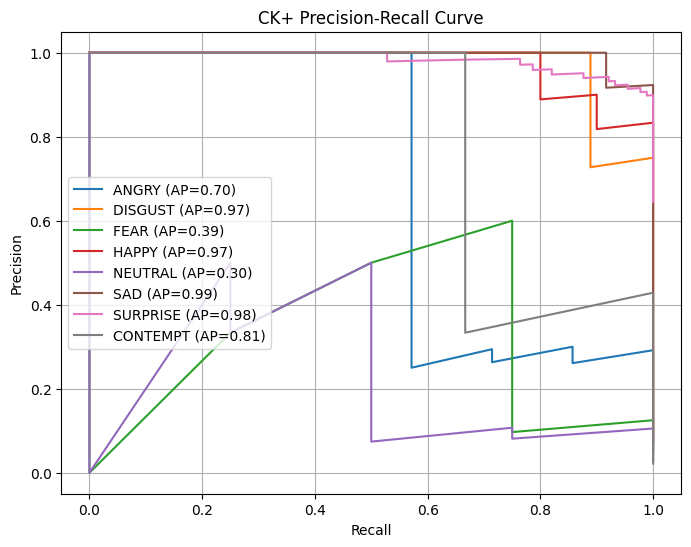

Mean Average Precision (mAP): 76.52%
Accuracy              : 87.68%
Precision (Weighted)  : 0.8188
Recall (Weighted)     : 0.8768
F1-Score (Weighted)   : 0.8384
Precision (Unweighted): 0.5778
Recall (Unweighted)   : 0.5293
F1-Score (Unweighted) : 0.5374
Cohen Kappa Score     : 0.7558
Matthews Corrcoef     : 0.7710

--- Classification Report ---

              precision    recall  f1-score   support

       ANGRY       1.00      0.43      0.60         7
     DISGUST       1.00      0.89      0.94         9
        FEAR       0.00      0.00      0.00         4
       HAPPY       0.83      1.00      0.91        10
     NEUTRAL       0.00      0.00      0.00         4
         SAD       0.92      0.92      0.92        12
    SURPRISE       0.87      1.00      0.93        89
    CONTEMPT       0.00      0.00      0.00         3

    accuracy                           0.88       138
   macro avg       0.58      0.53      0.54       138
weighted avg       0.82      0.88      0.84       138



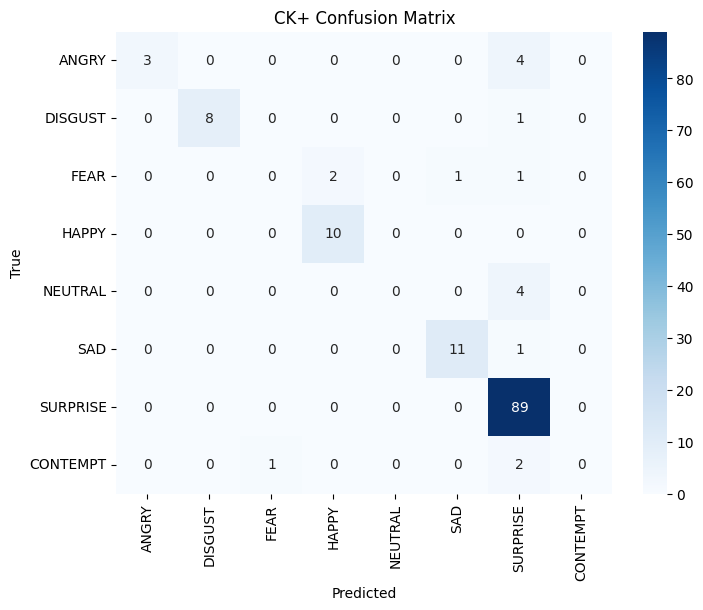

In [173]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator


# Re-initialize CK+ dataset variables and split data
data_path_ck = "/content/drive/MyDrive/Facial_Expression/ckextended.csv"
df_ck = pd.read_csv(data_path_ck)

img_rows_ck, img_cols_ck = 48, 48

X_ck_raw, y_ck_raw = [], []

for i in range(len(df_ck)):
    pixels = np.array(df_ck.iloc[i]['pixels'].split(), dtype='float32')
    img = pixels.reshape(img_rows_ck, img_cols_ck)
    X_ck_raw.append(img)
    y_ck_raw.append(df_ck.iloc[i]['emotion'])

X_ck_raw = np.array(X_ck_raw) / 255.0
X_ck_raw = X_ck_raw.reshape(-1, img_rows_ck, img_cols_ck, 1)
y_ck_raw = np.array(y_ck_raw)

num_classes_ck = len(np.unique(y_ck_raw))

Y_ck = to_categorical(y_ck_raw, num_classes_ck)

X_train_ck, X_test_ck, y_train_ck, y_test_ck = train_test_split(
    X_ck_raw, Y_ck, test_size=0.15, random_state=42, stratify=y_ck_raw
)

# Re-define datagen
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

# Re-define model_ck
model_ck = Sequential()

model_ck.add(Conv2D(32,(3,3),padding='same',activation='relu',input_shape=(img_rows_ck,img_cols_ck,1)))
model_ck.add(MaxPooling2D(2,2))
model_ck.add(Dropout(0.25))

model_ck.add(Conv2D(64,(3,3),padding='same',activation='relu'))
model_ck.add(MaxPooling2D(2,2))
model_ck.add(Dropout(0.25))

model_ck.add(Conv2D(128,(3,3),padding='same',activation='relu'))
model_ck.add(MaxPooling2D(2,2))
model_ck.add(Dropout(0.30))

model_ck.add(Flatten())
model_ck.add(Dense(256,activation='relu'))
model_ck.add(Dropout(0.50))
model_ck.add(Dense(num_classes_ck,activation='softmax'))

model_ck.compile(
    optimizer=Adam(learning_rate=0.0004),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Re-train model_ck (verbose=0 to suppress extensive output)
hist_ck = model_ck.fit(
    datagen.flow(X_train_ck, y_train_ck, batch_size=32),
    epochs=80,
    validation_data=(X_test_ck, y_test_ck),
    verbose=0
)

ck_emotion_labels = ['ANGRY', 'DISGUST', 'FEAR', 'HAPPY', 'NEUTRAL', 'SAD', 'SURPRISE', 'CONTEMPT']

ck_metrics = evaluate_model(
    model_ck,
    X_test_ck,
    y_test_ck,
    ck_emotion_labels,
    "CK+"
)

In [174]:
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    precision_score, recall_score, f1_score,
    cohen_kappa_score, matthews_corrcoef, roc_auc_score
)
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tensorflow.keras.callbacks import CSVLogger, ModelCheckpoint
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import os, cv2
from sklearn.utils import shuffle

In [175]:
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    precision_score, recall_score, f1_score,
    cohen_kappa_score, matthews_corrcoef,
    precision_recall_curve, average_precision_score
)

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.utils import to_categorical


def evaluate_model(model, X_test, y_test, class_names, dataset_name):

    print(f"\n================ {dataset_name} Evaluation Metrics =================\n")

    # Ensure one-hot encoding
    if len(y_test.shape) == 1:
        y_test = to_categorical(y_test)

    num_classes = y_test.shape[1]

    # Predictions
    y_pred_prob = model.predict(X_test)
    y_pred = np.argmax(y_pred_prob, axis=1)
    y_true = np.argmax(y_test, axis=1)

    # =========================
    # Precision-Recall Curves
    # =========================
    plt.figure(figsize=(8,6))
    ap_scores = []

    for i in range(num_classes):
        precision, recall, _ = precision_recall_curve(y_test[:, i], y_pred_prob[:, i])
        ap = average_precision_score(y_test[:, i], y_pred_prob[:, i])
        ap_scores.append(ap)

        plt.plot(recall, precision, label=f'{class_names[i]} (AP={ap:.2f})')

    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'{dataset_name} Precision-Recall Curve')
    plt.legend()
    plt.grid()
    plt.show()

    # TRUE mAP
    mean_average_precision = np.mean(ap_scores)

    # =========================
    # Metrics
    # =========================
    acc = accuracy_score(y_true, y_pred)
    precision_weighted = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall_weighted = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1_weighted = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    precision_unweighted = precision_score(y_true, y_pred, average='macro', zero_division=0)
    recall_unweighted = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1_unweighted = f1_score(y_true, y_pred, average='macro', zero_division=0)

    kappa = cohen_kappa_score(y_true, y_pred)
    mcc = matthews_corrcoef(y_true, y_pred)

    print(f"Accuracy              : {acc*100:.2f}%")
    print(f"Precision (Weighted)  : {precision_weighted:.4f}")
    print(f"Recall (Weighted)     : {recall_weighted:.4f}")
    print(f"F1-Score (Weighted)   : {f1_weighted:.4f}")
    print(f"Precision (Unweighted): {precision_unweighted:.4f}")
    print(f"Recall (Unweighted)   : {recall_unweighted:.4f}")
    print(f"F1-Score (Unweighted) : {f1_unweighted:.4f}")
    print(f"Cohen Kappa Score     : {kappa:.4f}")
    print(f"Matthews Corrcoef     : {mcc:.4f}")
    print(f"Mean Average Precision: {mean_average_precision*100:.2f}%")

    # Classification Report
    print("\n--- Classification Report ---\n")
    print(classification_report(
        y_true, y_pred,
        labels=np.arange(len(class_names)),
        target_names=class_names,
        zero_division=0
    ))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names)

    plt.title(f"{dataset_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    return {
        'accuracy': acc,
        'precision_weighted': precision_weighted,
        'recall_weighted': recall_weighted,
        'f1_weighted': f1_weighted,
        'precision_unweighted': precision_unweighted,
        'recall_unweighted': recall_unweighted,
        'f1_unweighted': f1_unweighted,
        'kappa': kappa,
        'mcc': mcc,
        'mean_average_precision': mean_average_precision
    }

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



================ FER2013 Evaluation Metrics =================

169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


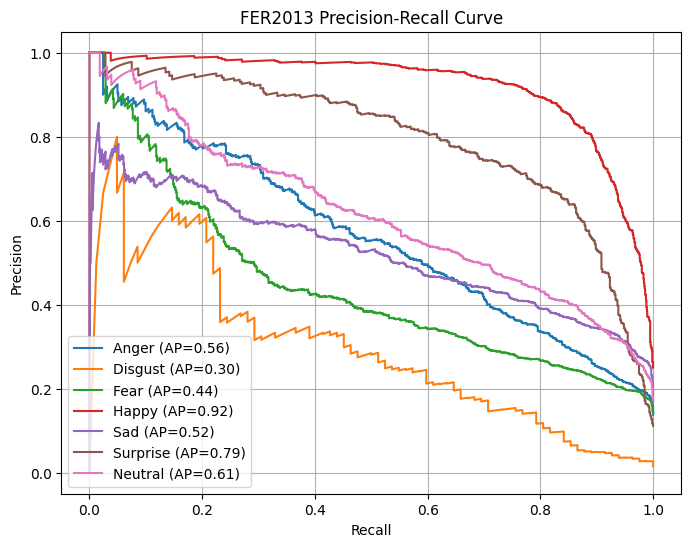

Accuracy              : 61.16%
Precision (Weighted)  : 0.6132
Recall (Weighted)     : 0.6116
F1-Score (Weighted)   : 0.5988
Precision (Unweighted): 0.5892
Recall (Unweighted)   : 0.5399
F1-Score (Unweighted) : 0.5422
Cohen Kappa Score     : 0.5283
Matthews Corrcoef     : 0.5336
Mean Average Precision: 59.44%

--- Classification Report ---

              precision    recall  f1-score   support

       Anger       0.53      0.53      0.53       743
     Disgust       0.55      0.21      0.30        82
        Fear       0.51      0.25      0.34       768
       Happy       0.83      0.85      0.84      1349
         Sad       0.54      0.43      0.48       912
    Surprise       0.69      0.76      0.73       600
     Neutral       0.47      0.75      0.58       930

    accuracy                           0.61      5384
   macro avg       0.59      0.54      0.54      5384
weighted avg       0.61      0.61      0.60      5384



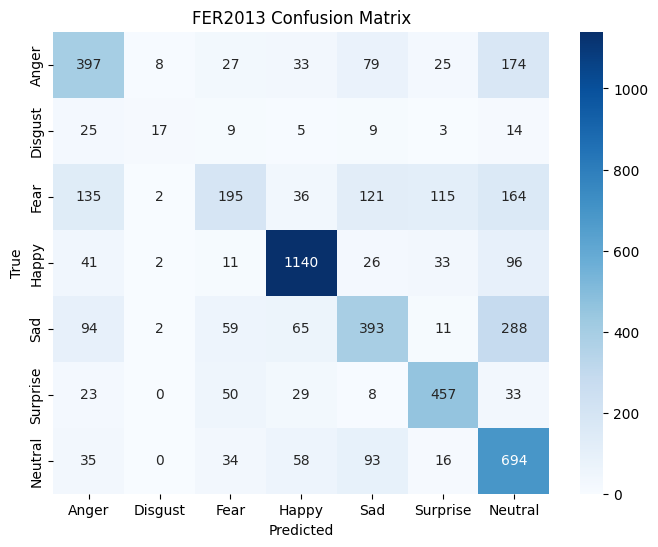

In [176]:
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    precision_score, recall_score, f1_score,
    cohen_kappa_score, matthews_corrcoef, roc_auc_score
)
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tensorflow.keras.callbacks import CSVLogger, ModelCheckpoint
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import os, cv2
from sklearn.utils import shuffle

# Re-initialize FER2013 dataset variables and split data
data_path_fer = "/content/drive/MyDrive/Facial_Expression/fer2013.csv"
df_fer = pd.read_csv(data_path_fer)

img_rows_fer, img_cols_fer = 48, 48
num_classes_fer = 7 # For FER2013, still 7 classes

X_fer_raw, y_fer_raw = [], []

for i in range(len(df_fer)):
    pixels = np.array(df_fer['pixels'][i].split(), dtype='float32')
    img = pixels.reshape(img_rows_fer, img_cols_fer)
    X_fer_raw.append(img)
    y_fer_raw.append(df_fer['emotion'][i])

X_fer_raw = np.array(X_fer_raw) / 255.0
X_fer_raw = X_fer_raw.reshape(-1, img_rows_fer, img_cols_fer, 1)
y_fer_raw = np.array(y_fer_raw)

Y_fer = to_categorical(y_fer_raw, num_classes_fer)

X_train_fer, X_test_fer, y_train_fer, y_test_fer = train_test_split(
    X_fer_raw, Y_fer, test_size=0.15, random_state=42, stratify=y_fer_raw
)

# Re-define datagen for FER2013
datagen_fer = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

# Re-define model for FER2013
model_fer = Sequential()

model_fer.add(Conv2D(32,(3,3),padding='same',activation='relu',input_shape=(img_rows_fer,img_cols_fer,1)))
model_fer.add(MaxPooling2D(2,2))
model_fer.add(Dropout(0.25))

model_fer.add(Conv2D(64,(3,3),padding='same',activation='relu'))
model_fer.add(MaxPooling2D(2,2))
model_fer.add(Dropout(0.25))

model_fer.add(Conv2D(128,(3,3),padding='same',activation='relu'))
model_fer.add(MaxPooling2D(2,2))
model_fer.add(Dropout(0.25))

model_fer.add(Flatten())
model_fer.add(Dense(256,activation='relu'))
model_fer.add(Dropout(0.5))
model_fer.add(Dense(num_classes_fer,activation='softmax'))

model_fer.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Retrain model_fer
hist_fer = model_fer.fit(
    datagen_fer.flow(X_train_fer, y_train_fer, batch_size=64),
    epochs=50,
    validation_data=(X_test_fer, y_test_fer),
    verbose=0 # Set verbose to 0 to suppress extensive output
)

fer_emotion_labels = ['Anger','Disgust','Fear','Happy','Sad','Surprise','Neutral']
fer_metrics = evaluate_model(
    model_fer,
    X_test_fer,
    y_test_fer,
    fer_emotion_labels,
    "FER2013"
)

In [177]:
import pandas as pd

# Create a dictionary to hold the metrics for each model
metrics_data = {
    'Model': ['Jeffe', 'CK+', 'FER2013'],
    'Accuracy': [jeffe_metrics['accuracy'], ck_metrics['accuracy'], fer_metrics['accuracy']],
    'Precision (Weighted)': [jeffe_metrics['precision_weighted'], ck_metrics['precision_weighted'], fer_metrics['precision_weighted']],
    'Recall (Weighted)': [jeffe_metrics['recall_weighted'], ck_metrics['recall_weighted'], fer_metrics['recall_weighted']],
    'F1-Score (Weighted)': [jeffe_metrics['f1_weighted'], ck_metrics['f1_weighted'], fer_metrics['f1_weighted']],
    'Precision (Unweighted)': [jeffe_metrics['precision_unweighted'], ck_metrics['precision_unweighted'], fer_metrics['precision_unweighted']],
    'Recall (Unweighted)': [jeffe_metrics['recall_unweighted'], ck_metrics['recall_unweighted'], fer_metrics['recall_unweighted']],
    'F1-Score (Unweighted)': [jeffe_metrics['f1_unweighted'], ck_metrics['f1_unweighted'], fer_metrics['f1_unweighted']],
    'Cohen Kappa Score': [jeffe_metrics['kappa'], ck_metrics['kappa'], fer_metrics['kappa']],
    'Matthews Corrcoef': [jeffe_metrics['mcc'], ck_metrics['mcc'], fer_metrics['mcc']],
    'Mean Average Precision': [jeffe_metrics['mean_average_precision'], ck_metrics['mean_average_precision'], fer_metrics['mean_average_precision']]
}

# Create a Pandas DataFrame
metrics_df = pd.DataFrame(metrics_data)

# Print the comparative table
print("\n=================== Comparative Model Performance ===================")
print(metrics_df.to_string(index=False))
print("=====================================================================")


=================== Comparative Model Performance ===================
  Model  Accuracy  Precision (Weighted)  Recall (Weighted)  F1-Score (Weighted)  Precision (Unweighted)  Recall (Unweighted)  F1-Score (Unweighted)  Cohen Kappa Score  Matthews Corrcoef  Mean Average Precision
  Jeffe  0.968750              0.973214           0.968750             0.968216                0.976190             0.966667               0.968661           0.961023           0.962198                0.857143
    CK+  0.876812              0.818770           0.876812             0.838434                0.577819             0.529266               0.537359           0.755752           0.771010                0.765164
FER2013  0.611627              0.613175           0.611627             0.598799                0.589236             0.539920               0.542161           0.528321           0.533636                0.594405


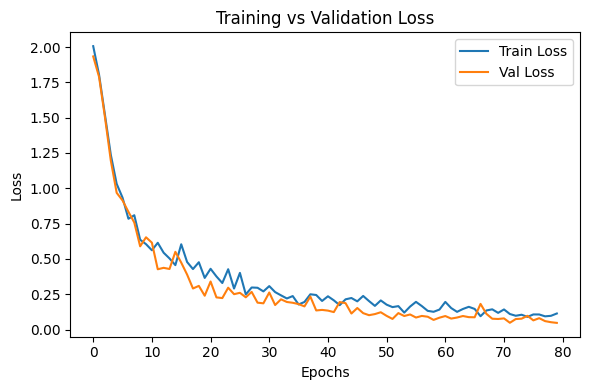

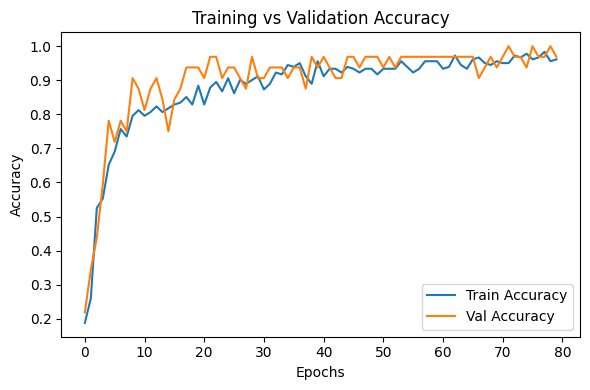

In [178]:
import matplotlib.pyplot as plt

# Assuming hist_jeffe contains the training history for the Jeffe model
train_loss = hist_jeffe.history['loss']
val_loss   = hist_jeffe.history['val_loss']
train_acc  = hist_jeffe.history['accuracy']
val_acc    = hist_jeffe.history['val_accuracy']

epochs = range(len(train_acc))

# Loss plot
plt.figure(figsize=(6,4))
plt.plot(epochs, train_loss, label='Train Loss')
plt.plot(epochs, val_loss, label='Val Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

# Accuracy plot
plt.figure(figsize=(6,4))
plt.plot(epochs, train_acc, label='Train Accuracy')
plt.plot(epochs, val_acc, label='Val Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

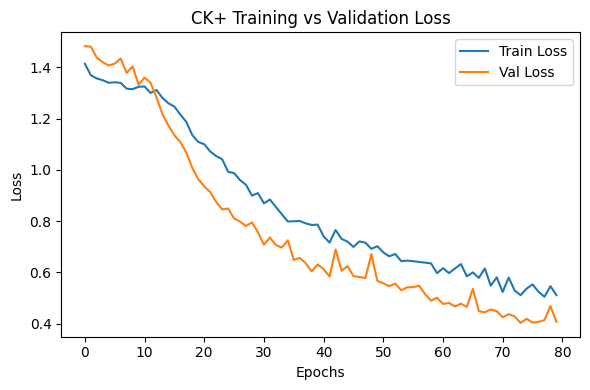

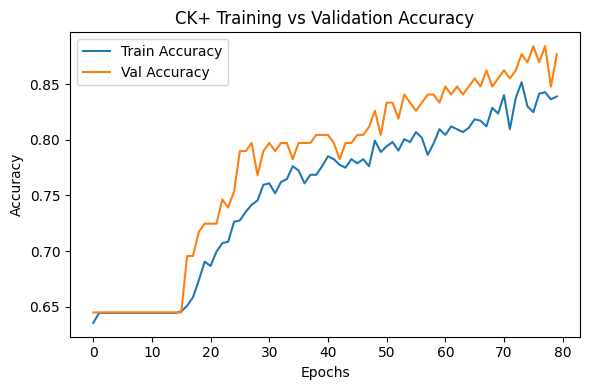

In [179]:
import matplotlib.pyplot as plt

# Assuming hist_ck contains the training history for the CK+ model
train_loss_ck = hist_ck.history['loss']
val_loss_ck   = hist_ck.history['val_loss']
train_acc_ck  = hist_ck.history['accuracy']
val_acc_ck    = hist_ck.history['val_accuracy']

epochs_ck = range(len(train_acc_ck))

# Loss plot
plt.figure(figsize=(6,4))
plt.plot(epochs_ck, train_loss_ck, label='Train Loss')
plt.plot(epochs_ck, val_loss_ck, label='Val Loss')
plt.title('CK+ Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

# Accuracy plot
plt.figure(figsize=(6,4))
plt.plot(epochs_ck, train_acc_ck, label='Train Accuracy')
plt.plot(epochs_ck, val_acc_ck, label='Val Accuracy')
plt.title('CK+ Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

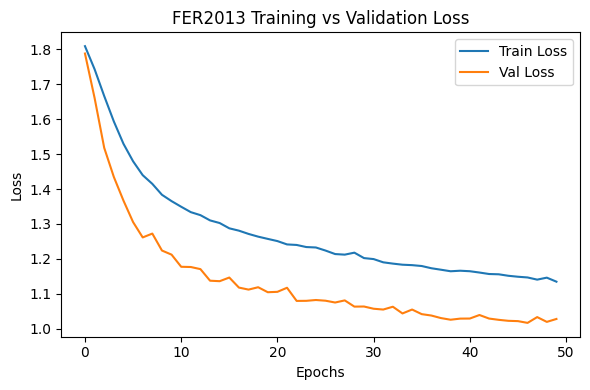

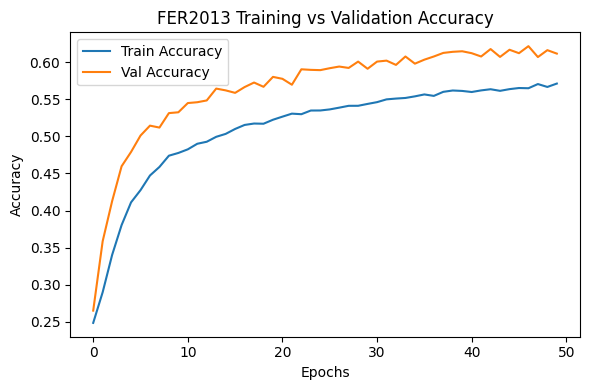

In [180]:
import matplotlib.pyplot as plt

# Assuming hist_fer contains the training history for the FER2013 model
train_loss_fer = hist_fer.history['loss']
val_loss_fer   = hist_fer.history['val_loss']
train_acc_fer  = hist_fer.history['accuracy']
val_acc_fer    = hist_fer.history['val_accuracy']

epochs_fer = range(len(train_acc_fer))

# Loss plot
plt.figure(figsize=(6,4))
plt.plot(epochs_fer, train_loss_fer, label='Train Loss')
plt.plot(epochs_fer, val_loss_fer, label='Val Loss')
plt.title('FER2013 Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

# Accuracy plot
plt.figure(figsize=(6,4))
plt.plot(epochs_fer, train_acc_fer, label='Train Accuracy')
plt.plot(epochs_fer, val_acc_fer, label='Val Accuracy')
plt.title('FER2013 Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

In [181]:
import os, cv2
import numpy as np

ck_data_dir = '/content/drive/MyDrive/Facial_Expression/CK+/'

X_ck_raw_dir = []
y_ck_raw_dir = []

img_rows, img_cols = 48, 48

# Define CK+ emotion labels (standardized to uppercase for mapping)
ck_emotion_labels = ['ANGRY', 'DISGUST', 'FEAR', 'HAPPY', 'NEUTRAL', 'SAD', 'SURPRISE', 'CONTEMPT']

# Create a mapping from standardized emotion names to integer labels
emotion_to_int = {emotion: i for i, emotion in enumerate(ck_emotion_labels)}

print("Loading images from directory...")

# Iterate through each item in the base CK+ directory
for emotion_folder_name in os.listdir(ck_data_dir):
    emotion_path = os.path.join(ck_data_dir, emotion_folder_name)

    # Check if it's a directory (representing an emotion category)
    if os.path.isdir(emotion_path):
        # Standardize the folder name to uppercase for mapping
        standardized_emotion_name = emotion_folder_name.upper()

        if standardized_emotion_name not in emotion_to_int:
            # Handle cases where folder names might not exactly match (e.g., 'sadness' vs 'SAD')
            # A more robust mapping might be needed if variations exist.
            # For now, let's assume 'sadness' -> 'SAD', 'anger' -> 'ANGRY' etc.
            # If 'sadness' is a folder name, it means the dataset uses different naming conventions than the labels.
            # Let's adjust for common variations or make sure our ck_emotion_labels match actual folder names.
            if emotion_folder_name.lower() == 'sadness': # Specific mapping for 'sadness'
                standardized_emotion_name = 'SAD'
            elif emotion_folder_name.lower() == 'anger': # Specific mapping for 'anger'
                standardized_emotion_name = 'ANGRY'
            elif emotion_folder_name.lower() == 'disgust':
                standardized_emotion_name = 'DISGUST'
            elif emotion_folder_name.lower() == 'fear':
                standardized_emotion_name = 'FEAR'
            elif emotion_folder_name.lower() == 'happy':
                standardized_emotion_name = 'HAPPY'
            elif emotion_folder_name.lower() == 'neutral':
                standardized_emotion_name = 'NEUTRAL'
            elif emotion_folder_name.lower() == 'surprise':
                standardized_emotion_name = 'SURPRISE'
            elif emotion_folder_name.lower() == 'contempt':
                standardized_emotion_name = 'CONTEMPT'
            else:
                print(f"Warning: Folder name '{emotion_folder_name}' not found in ck_emotion_labels. Skipping.")
                continue

        # Ensure the standardized name is now in the map
        if standardized_emotion_name not in emotion_to_int:
            print(f"Error: Standardized emotion '{standardized_emotion_name}' still not in map for folder '{emotion_folder_name}'. Skipping.")
            continue

        emotion_label_int = emotion_to_int[standardized_emotion_name]

        # Iterate directly over files within the emotion category folder
        for img_name in os.listdir(emotion_path):
            img_path = os.path.join(emotion_path, img_name)

            if not os.path.isfile(img_path): # Ensure it's a file, not a nested directory
                continue

            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                print(f"Warning: Could not load image {img_path}. Skipping.")
                continue

            img = cv2.resize(img, (img_rows, img_cols))
            X_ck_raw_dir.append(img)
            y_ck_raw_dir.append(emotion_label_int)

print(f"Finished loading images. Total images found: {len(X_ck_raw_dir)}")
print(f"Total labels found: {len(y_ck_raw_dir)}")


Loading images from directory...
Finished loading images. Total images found: 981
Total labels found: 981


In [182]:
X_ck_raw_dir = np.array(X_ck_raw_dir, dtype='float32') / 255.0
X_ck_raw_dir = X_ck_raw_dir.reshape(-1, img_rows, img_cols, 1)
y_ck_raw_dir = np.array(y_ck_raw_dir)

print("CK+ Images (from directory):", X_ck_raw_dir.shape)
print("CK+ Labels (from directory):", y_ck_raw_dir.shape)

CK+ Images (from directory): (981, 48, 48, 1)
CK+ Labels (from directory): (981,)


In [183]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# Determine the number of classes from the predefined emotion labels list
# This ensures all possible classes are accounted for, even if some are not present in the current dataset slice.
num_classes_ck_dir = len(ck_emotion_labels)

# Convert integer labels to one-hot encoded vectors
Y_ck_dir = to_categorical(y_ck_raw_dir, num_classes_ck_dir)

# Split the dataset into training and testing sets
X_train_ck_dir, X_test_ck_dir, y_train_ck_dir, y_test_ck_dir = train_test_split(
    X_ck_raw_dir, Y_ck_dir, test_size=0.15, random_state=42, stratify=y_ck_raw_dir
)

print("X_train_ck_dir shape:", X_train_ck_dir.shape)
print("X_test_ck_dir shape:", X_test_ck_dir.shape)
print("y_train_ck_dir shape:", y_train_ck_dir.shape)
print("y_test_ck_dir shape:", y_test_ck_dir.shape)
print("Number of classes for CK+ (from directory):", num_classes_ck_dir)

X_train_ck_dir shape: (833, 48, 48, 1)
X_test_ck_dir shape: (148, 48, 48, 1)
y_train_ck_dir shape: (833, 8)
y_test_ck_dir shape: (148, 8)
Number of classes for CK+ (from directory): 8


In [184]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense
from tensorflow.keras.optimizers import Adam

model_ck = Sequential()

model_ck.add(Conv2D(32,(3,3),padding='same',activation='relu',input_shape=(img_rows,img_cols,1)))
model_ck.add(MaxPooling2D(2,2))
model_ck.add(Dropout(0.25))

model_ck.add(Conv2D(64,(3,3),padding='same',activation='relu'))
model_ck.add(MaxPooling2D(2,2))
model_ck.add(Dropout(0.25))

model_ck.add(Conv2D(128,(3,3),padding='same',activation='relu'))
model_ck.add(MaxPooling2D(2,2))
model_ck.add(Dropout(0.30))

model_ck.add(Flatten())
model_ck.add(Dense(256,activation='relu'))
model_ck.add(Dropout(0.50))
model_ck.add(Dense(num_classes_ck_dir,activation='softmax')) # Changed to num_classes_ck_dir

model_ck.compile(
    optimizer=Adam(learning_rate=0.0004),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_ck.summary()
print("CK+ model architecture defined and compiled.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_31"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_93 (Conv2D)              │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_65 (MaxPooling2D) │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_60 (Dropout)            │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_94 (Conv2D)              │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_66 (MaxPooling2D) │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_61 (Dropout)            │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_95 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_67 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_62 (Dropout)            │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_31 (Flatten)            │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_62 (Dense)                │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_63 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_63 (Dense)                │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,274,632 (4.86 MB)

 Trainable params: 1,274,632 (4.86 MB)

 Non-trainable params: 0 (0.00 B)

CK+ model architecture defined and compiled.


In [185]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

model_ck = Sequential()

model_ck.add(Conv2D(32,(3,3),padding='same',activation='relu',input_shape=(img_rows,img_cols,1)))
model_ck.add(MaxPooling2D(2,2))
model_ck.add(Dropout(0.25))

model_ck.add(Conv2D(64,(3,3),padding='same',activation='relu'))
model_ck.add(MaxPooling2D(2,2))
model_ck.add(Dropout(0.25))

model_ck.add(Conv2D(128,(3,3),padding='same',activation='relu'))
model_ck.add(MaxPooling2D(2,2))
model_ck.add(Dropout(0.30))

model_ck.add(Flatten())
model_ck.add(Dense(256,activation='relu'))
model_ck.add(Dropout(0.50))
model_ck.add(Dense(num_classes_ck_dir,activation='softmax')) # Changed to num_classes_ck_dir

model_ck.compile(
    optimizer=Adam(learning_rate=0.0004),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_ck.summary()
print("CK+ model architecture defined and compiled.")

datagen_ck = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

hist_ck = model_ck.fit(
    datagen_ck.flow(X_train_ck_dir, y_train_ck_dir, batch_size=32),
    epochs=50,
    validation_data=(X_test_ck_dir, y_test_ck_dir),
    verbose=1
)

Model: "sequential_32"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_96 (Conv2D)              │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_68 (MaxPooling2D) │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_64 (Dropout)            │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_97 (Conv2D)              │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_69 (MaxPooling2D) │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_65 (Dropout)            │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_98 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_70 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_66 (Dropout)            │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_32 (Flatten)            │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_67 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_65 (Dense)                │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,274,632 (4.86 MB)

 Trainable params: 1,274,632 (4.86 MB)

 Non-trainable params: 0 (0.00 B)

CK+ model architecture defined and compiled.
Epoch 1/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 12s 206ms/step - accuracy: 0.2161 - loss: 1.9164 - val_accuracy: 0.3041 - val_loss: 1.9274
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.2353 - loss: 1.8779 - val_accuracy: 0.2568 - val_loss: 1.9204
Epoch 3/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.2413 - loss: 1.8529 - val_accuracy: 0.2703 - val_loss: 1.9427
Epoch 4/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.2389 - loss: 1.8673 - val_accuracy: 0.2568 - val_loss: 1.9259
Epoch 5/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.2437 - loss: 1.8371 - val_accuracy: 0.2635 - val_loss: 1.8704
Epoch 6/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.2641 - loss: 1.8392 - val_accuracy: 0.2568 - val_loss: 1.8954
Epoch 7/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.2725 - loss: 1.8162 - val_accuracy: 0.2568 - val_loss: 1.7688
Epoch 8/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0

In [186]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

model_ck = Sequential()

model_ck.add(Conv2D(32,(3,3),padding='same',activation='relu',input_shape=(img_rows,img_cols,1)))
model_ck.add(MaxPooling2D(2,2))
model_ck.add(Dropout(0.25))

model_ck.add(Conv2D(64,(3,3),padding='same',activation='relu'))
model_ck.add(MaxPooling2D(2,2))
model_ck.add(Dropout(0.25))

model_ck.add(Conv2D(128,(3,3),padding='same',activation='relu'))
model_ck.add(MaxPooling2D(2,2))
model_ck.add(Dropout(0.30))

model_ck.add(Flatten())
model_ck.add(Dense(256,activation='relu'))
model_ck.add(Dropout(0.50))
model_ck.add(Dense(num_classes_ck_dir,activation='softmax')) # Changed to num_classes_ck_dir

model_ck.compile(
    optimizer=Adam(learning_rate=0.0004),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_ck.summary()
print("CK+ model architecture defined and compiled.")

datagen_ck = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

hist_ck = model_ck.fit(
    datagen_ck.flow(X_train_ck_dir, y_train_ck_dir, batch_size=32),
    epochs=50,
    validation_data=(X_test_ck_dir, y_test_ck_dir),
    verbose=1
)

Model: "sequential_33"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_99 (Conv2D)              │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_71 (MaxPooling2D) │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_68 (Dropout)            │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_100 (Conv2D)             │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_72 (MaxPooling2D) │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_69 (Dropout)            │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_101 (Conv2D)             │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_73 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_70 (Dropout)            │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_33 (Flatten)            │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_66 (Dense)                │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_71 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_67 (Dense)                │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,274,632 (4.86 MB)

 Trainable params: 1,274,632 (4.86 MB)

 Non-trainable params: 0 (0.00 B)

CK+ model architecture defined and compiled.
Epoch 1/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 12s 239ms/step - accuracy: 0.2101 - loss: 1.9159 - val_accuracy: 0.2568 - val_loss: 1.9206
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.2245 - loss: 1.8843 - val_accuracy: 0.2568 - val_loss: 1.8664
Epoch 3/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.2365 - loss: 1.8579 - val_accuracy: 0.2568 - val_loss: 1.8903
Epoch 4/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.2377 - loss: 1.8548 - val_accuracy: 0.2568 - val_loss: 1.9048
Epoch 5/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.2917 - loss: 1.8321 - val_accuracy: 0.3243 - val_loss: 1.8904
Epoch 6/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.2605 - loss: 1.8165 - val_accuracy: 0.3514 - val_loss: 1.8391
Epoch 7/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.3085 - loss: 1.7921 - val_accuracy: 0.2973 - val_loss: 1.7485
Epoch 8/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0

In [187]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

model_ck = Sequential()

model_ck.add(Conv2D(32,(3,3),padding='same',activation='relu',input_shape=(img_rows,img_cols,1)))
model_ck.add(MaxPooling2D(2,2))
model_ck.add(Dropout(0.25))

model_ck.add(Conv2D(64,(3,3),padding='same',activation='relu'))
model_ck.add(MaxPooling2D(2,2))
model_ck.add(Dropout(0.25))

model_ck.add(Conv2D(128,(3,3),padding='same',activation='relu'))
model_ck.add(MaxPooling2D(2,2))
model_ck.add(Dropout(0.30))

model_ck.add(Flatten())
model_ck.add(Dense(256,activation='relu'))
model_ck.add(Dropout(0.50))
model_ck.add(Dense(num_classes_ck_dir,activation='softmax')) # Changed to num_classes_ck_dir

model_ck.compile(
    optimizer=Adam(learning_rate=0.0004),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_ck.summary()
print("CK+ model architecture defined and compiled.")

datagen_ck = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

hist_ck = model_ck.fit(
    datagen_ck.flow(X_train_ck_dir, y_train_ck_dir, batch_size=32),
    epochs=50,
    validation_data=(X_test_ck_dir, y_test_ck_dir),
    verbose=1
)

Model: "sequential_34"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_102 (Conv2D)             │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_74 (MaxPooling2D) │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_72 (Dropout)            │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_103 (Conv2D)             │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_75 (MaxPooling2D) │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_73 (Dropout)            │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_104 (Conv2D)             │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_76 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_74 (Dropout)            │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_34 (Flatten)            │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_68 (Dense)                │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_75 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_69 (Dense)                │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,274,632 (4.86 MB)

 Trainable params: 1,274,632 (4.86 MB)

 Non-trainable params: 0 (0.00 B)

CK+ model architecture defined and compiled.
Epoch 1/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 12s 286ms/step - accuracy: 0.2305 - loss: 1.9295 - val_accuracy: 0.2297 - val_loss: 1.9636
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.2473 - loss: 1.8714 - val_accuracy: 0.2568 - val_loss: 1.8834
Epoch 3/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.2605 - loss: 1.8618 - val_accuracy: 0.3649 - val_loss: 1.9091
Epoch 4/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.2569 - loss: 1.8562 - val_accuracy: 0.2432 - val_loss: 1.9247
Epoch 5/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.2701 - loss: 1.8392 - val_accuracy: 0.2568 - val_loss: 1.9216
Epoch 6/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.2425 - loss: 1.8462 - val_accuracy: 0.2635 - val_loss: 1.9173
Epoch 7/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.2641 - loss: 1.8355 - val_accuracy: 0.2838 - val_loss: 1.8686
Epoch 8/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0

In [188]:
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    precision_score, recall_score, f1_score,
    cohen_kappa_score, matthews_corrcoef,
    precision_recall_curve, average_precision_score
)

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.utils import to_categorical


def evaluate_model(model, X_test, y_test, class_names, dataset_name):

    print(f"\n================ {dataset_name} Evaluation Metrics =================\n")

    # Ensure one-hot encoding
    if len(y_test.shape) == 1:
        y_test = to_categorical(y_test)

    num_classes = y_test.shape[1]

    # Predictions
    y_pred_prob = model.predict(X_test)
    y_pred = np.argmax(y_pred_prob, axis=1)
    y_true = np.argmax(y_test, axis=1)

    # =========================
    # Precision-Recall Curves
    # =========================
    plt.figure(figsize=(8,6))
    ap_scores = []

    for i in range(num_classes):
        precision, recall, _ = precision_recall_curve(y_test[:, i], y_pred_prob[:, i])
        ap = average_precision_score(y_test[:, i], y_pred_prob[:, i])
        ap_scores.append(ap)

        plt.plot(recall, precision, label=f'{class_names[i]} (AP={ap:.2f})')

    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'{dataset_name} Precision-Recall Curve')
    plt.legend()
    plt.grid()
    plt.show()

    # TRUE mAP (correct definition)
    mean_average_precision = np.mean(ap_scores)

    # =========================
    # Metrics
    # =========================
    acc = accuracy_score(y_true, y_pred)
    precision_weighted = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall_weighted = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1_weighted = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    precision_unweighted = precision_score(y_true, y_pred, average='macro', zero_division=0)
    recall_unweighted = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1_unweighted = f1_score(y_true, y_pred, average='macro', zero_division=0)

    kappa = cohen_kappa_score(y_true, y_pred)
    mcc = matthews_corrcoef(y_true, y_pred)

    print(f"Accuracy              : {acc*100:.2f}%")
    print(f"Precision (Weighted)  : {precision_weighted:.4f}")
    print(f"Recall (Weighted)     : {recall_weighted:.4f}")
    print(f"F1-Score (Weighted)   : {f1_weighted:.4f}")
    print(f"Precision (Unweighted): {precision_unweighted:.4f}")
    print(f"Recall (Unweighted)   : {recall_unweighted:.4f}")
    print(f"F1-Score (Unweighted) : {f1_unweighted:.4f}")
    print(f"Cohen Kappa Score     : {kappa:.4f}")
    print(f"Matthews Corrcoef     : {mcc:.4f}")
    print(f"Mean Average Precision: {mean_average_precision*100:.2f}%")

    # Classification Report
    print("\n--- Classification Report ---\n")
    print(classification_report(
        y_true, y_pred,
        labels=np.arange(len(class_names)),
        target_names=class_names,
        zero_division=0
    ))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names)

    plt.title(f"{dataset_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    return {
        'accuracy': acc,
        'precision_weighted': precision_weighted,
        'recall_weighted': recall_weighted,
        'f1_weighted': f1_weighted,
        'precision_unweighted': precision_unweighted,
        'recall_unweighted': recall_unweighted,
        'f1_unweighted': f1_unweighted,
        'kappa': kappa,
        'mcc': mcc,
        'mean_average_precision': mean_average_precision
    }

Generating Per-Class Matrices for FER2013...
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


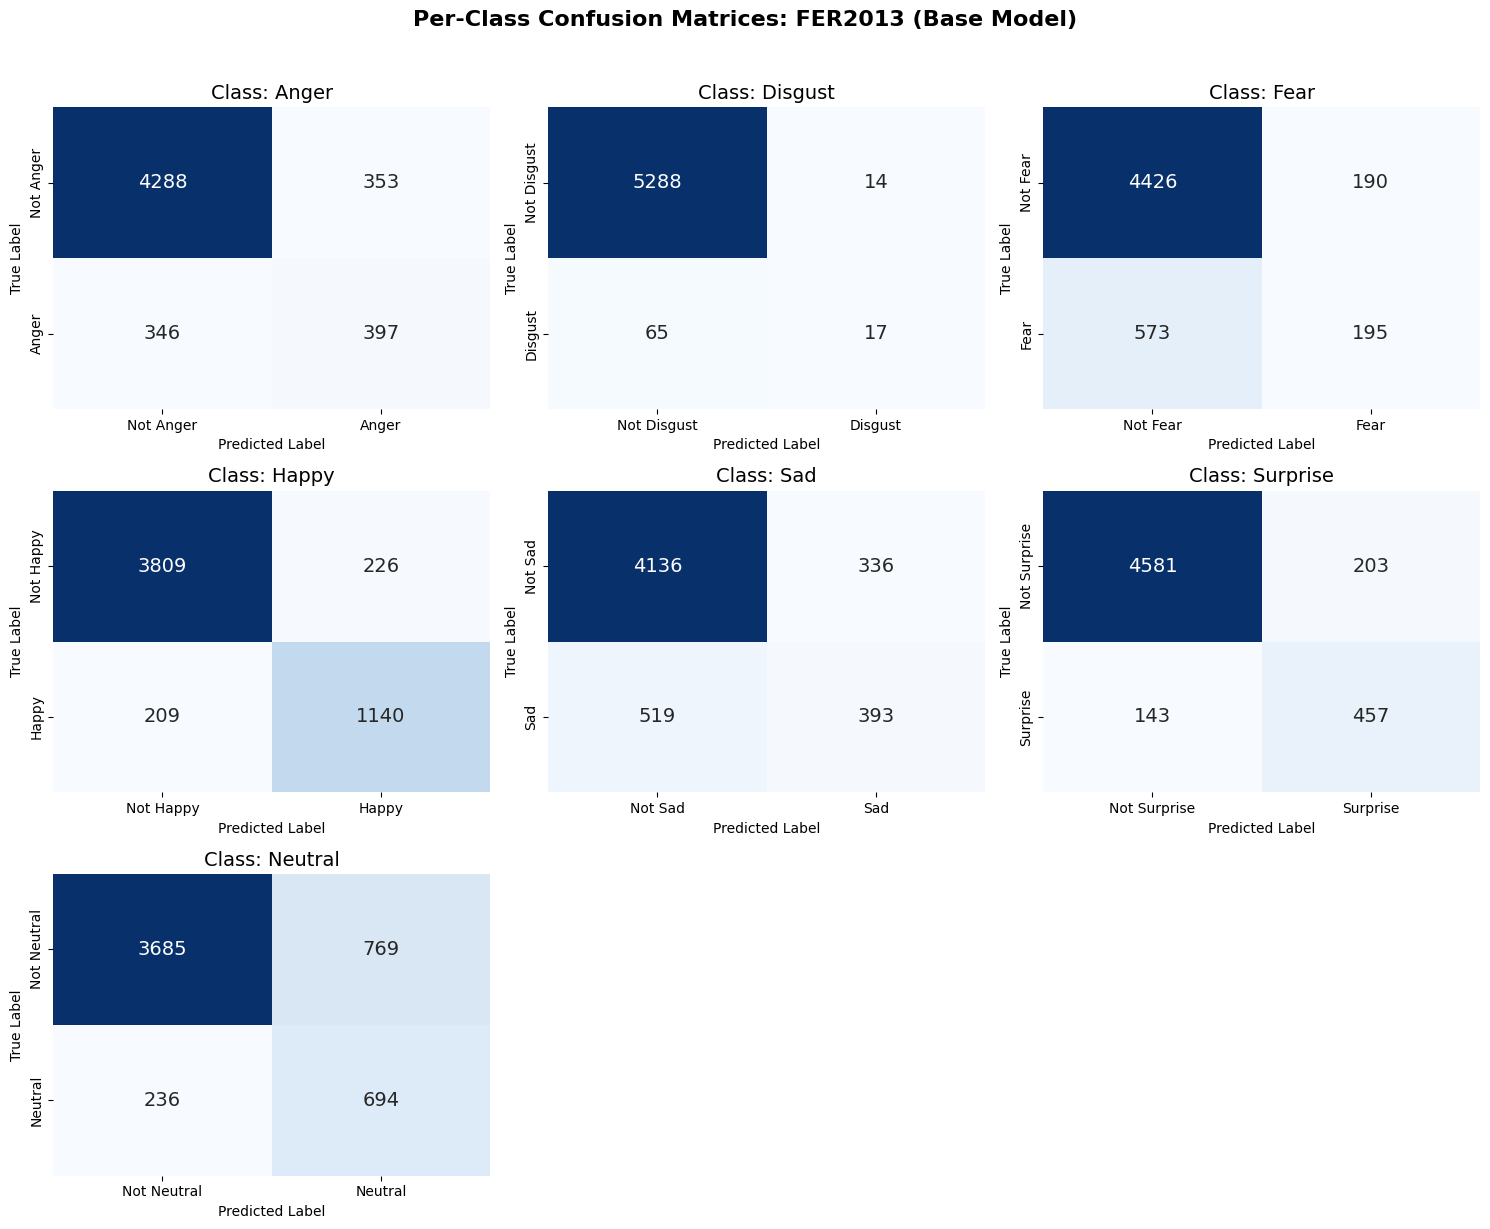


Generating Per-Class Matrices for CK+...
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


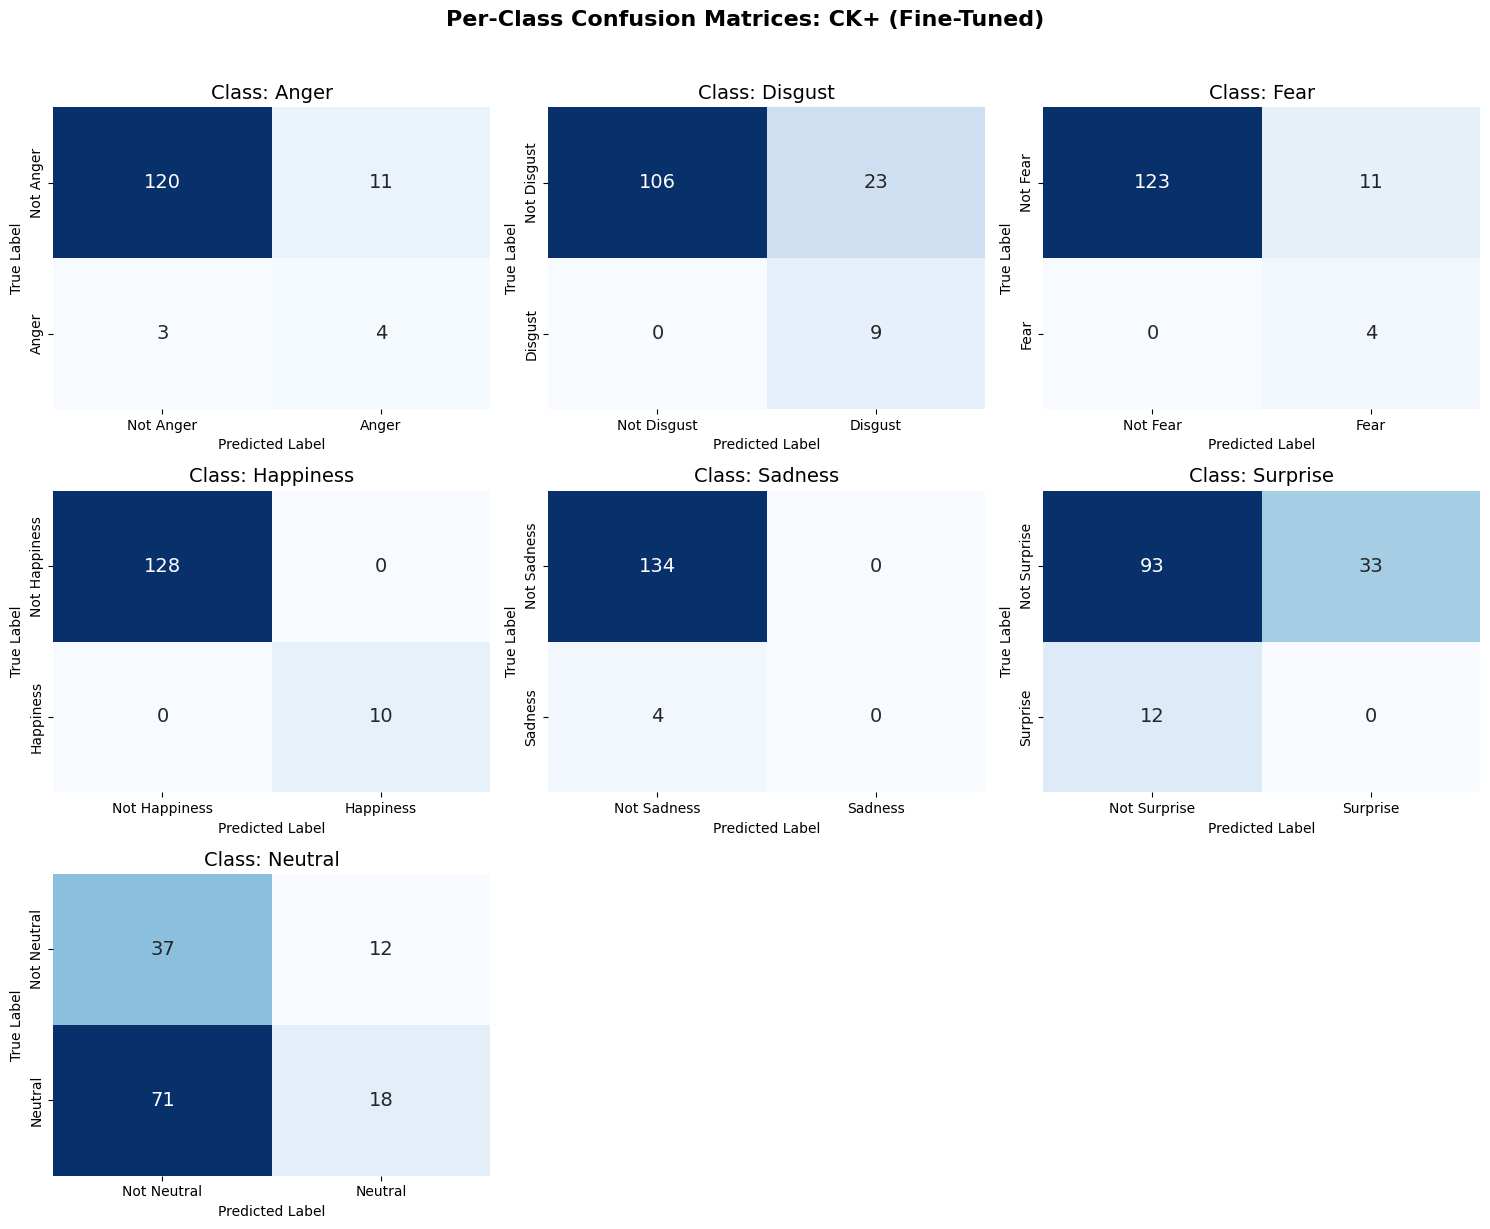


Generating Per-Class Matrices for JAFFE...


NameError: name 'model_jaffe' is not defined

In [190]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import multilabel_confusion_matrix

def plot_per_class_cm(y_true, y_pred_prob, labels, dataset_name):
    # 1. Convert probabilities/one-hot encoding to flat class indices
    if len(y_true.shape) > 1 and y_true.shape[1] > 1:
        y_true_idx = np.argmax(y_true, axis=1)
    else:
        y_true_idx = y_true

    y_pred_idx = np.argmax(y_pred_prob, axis=1)

    # 2. Generate per-class 2x2 confusion matrices
    # Structure: [[True Negative, False Positive], [False Negative, True Positive]]
    mcm = multilabel_confusion_matrix(y_true_idx, y_pred_idx)

    # 3. Setup the Matplotlib grid (3 columns, dynamic rows)
    num_classes = len(labels)
    cols = 3
    rows = int(np.ceil(num_classes / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows))
    fig.suptitle(f'Per-Class Confusion Matrices: {dataset_name}', fontsize=16, fontweight='bold', y=1.02)
    axes = axes.flatten()

    # 4. Plot each class as a separate heatmap
    for i, (matrix, label) in enumerate(zip(mcm, labels)):
        sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                    xticklabels=[f'Not {label}', f'{label}'],
                    yticklabels=[f'Not {label}', f'{label}'],
                    cbar=False, annot_kws={"size": 14})
        axes[i].set_title(f'Class: {label}', fontsize=14)
        axes[i].set_xlabel('Predicted Label')
        axes[i].set_ylabel('True Label')

    # 5. Hide any empty subplots in the grid
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

# =====================================================================
# EXECUTION BLOCK FOR 3 DATASETS
# =====================================================================

# Standardized labels based on your Colab outputs
fer_labels = ['Anger', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']
ck_labels = ['Anger', 'Disgust', 'Fear', 'Happiness', 'Sadness', 'Surprise', 'Neutral']
jaffe_labels = ['ANGRY', 'DISGUST', 'FEAR', 'HAPPY', 'NEUTRAL', 'SAD', 'SURPRISE']

print("Generating Per-Class Matrices for FER2013...")
# Uses model_fer, X_test_fer, y_test_fer from your notebook
pred_probs_fer = model_fer.predict(X_test_fer)
plot_per_class_cm(y_test_fer, pred_probs_fer, fer_labels, "FER2013 (Base Model)")

print("\nGenerating Per-Class Matrices for CK+...")
# Uses model_ck, X_test_ck, y_test_ck from your notebook
pred_probs_ck = model_ck.predict(X_test_ck)
plot_per_class_cm(y_test_ck, pred_probs_ck, ck_labels, "CK+ (Fine-Tuned)")

print("\nGenerating Per-Class Matrices for JAFFE...")
# Uses model, X_test, y_test from your notebook's JAFFE block
pred_probs_jaffe = model_jaffe.predict(X_test)
plot_per_class_cm(y_test, pred_probs_jaffe, jaffe_labels, "JAFFE (Fine-Tuned)")

In [195]:
input_shape = X_train.shape[1:]   # (128,128,1)
num_classes = y_train.shape[1]

model_jaffe = build_model_2(input_shape, num_classes, use_bn=True, use_dropout=True, lr=0.0001)

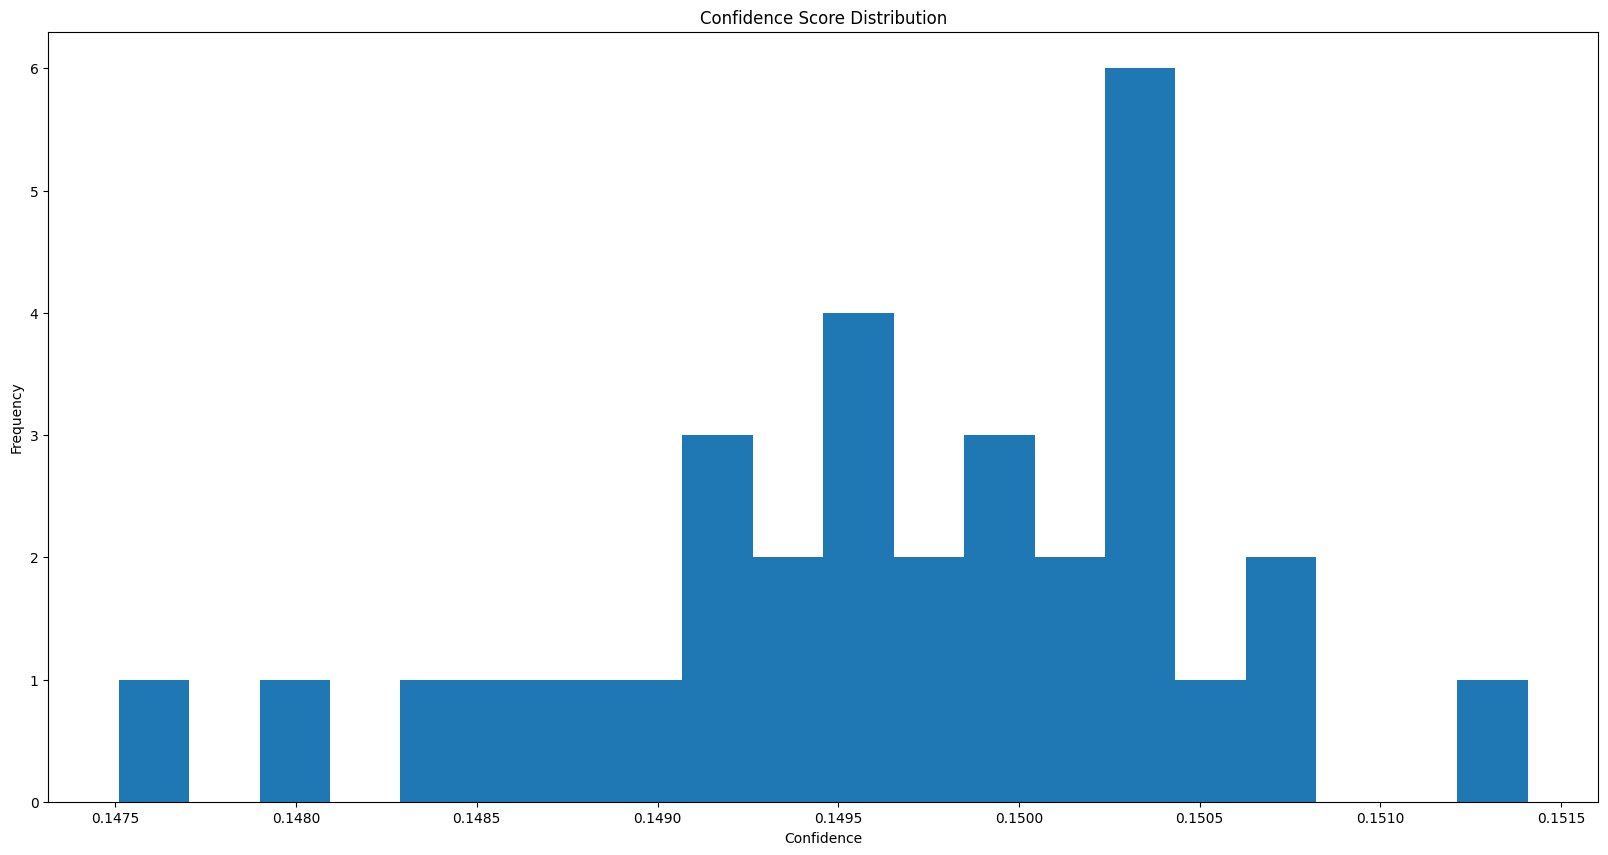

In [196]:
confidences = np.max(y_prob, axis=1)

plt.hist(confidences, bins=20)
plt.title("Confidence Score Distribution")
plt.xlabel("Confidence")
plt.ylabel("Frequency")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


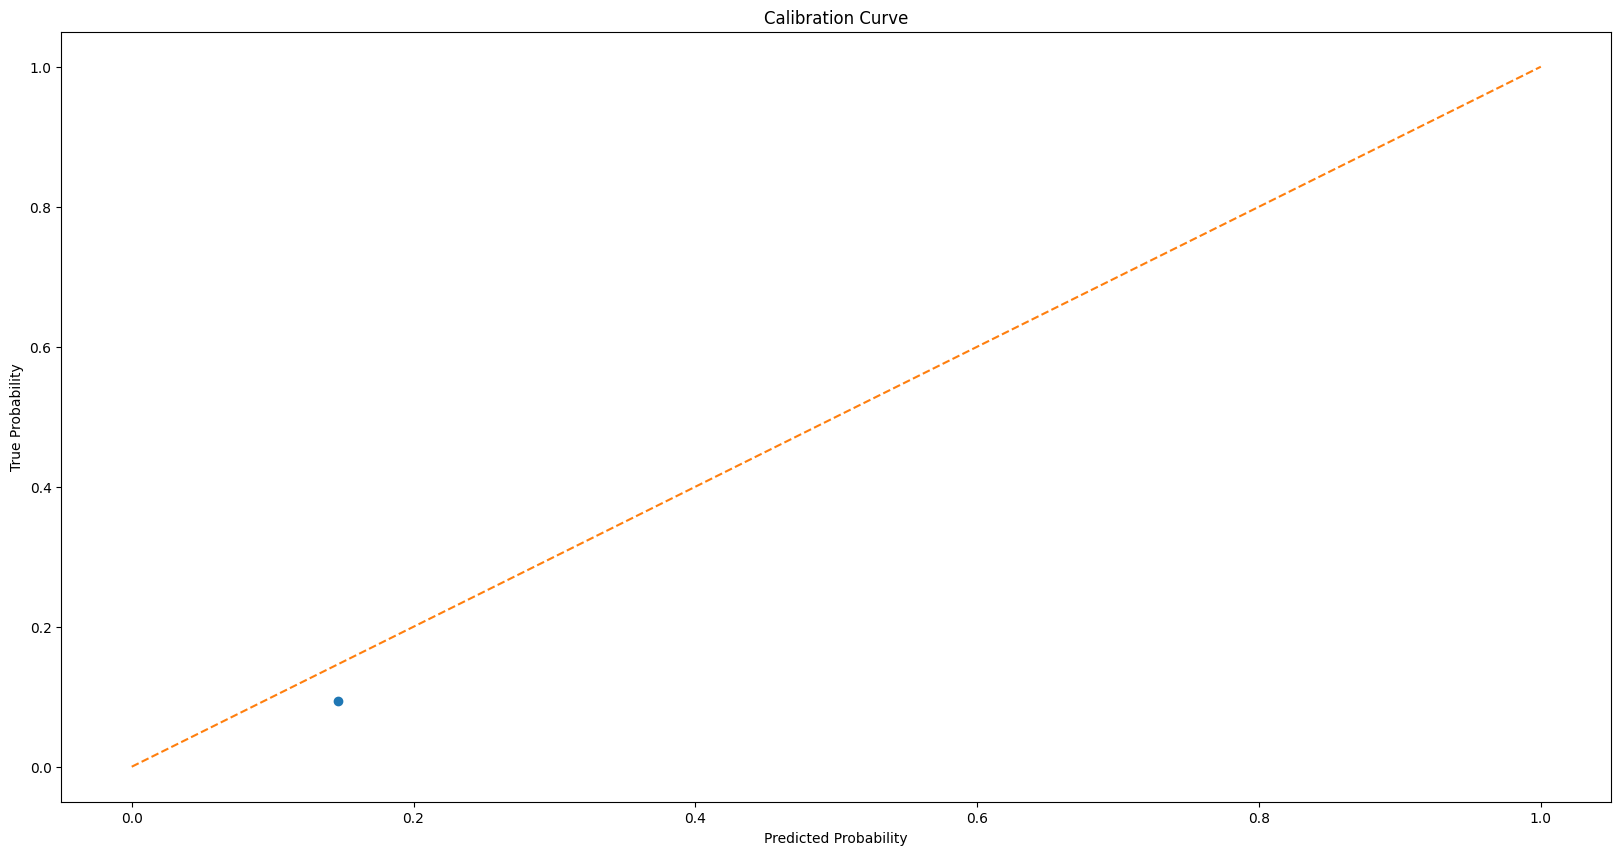

In [199]:
from sklearn.calibration import calibration_curve
import numpy as np
import matplotlib.pyplot as plt

# ✅ USE CORRECT MODEL
y_prob = model_jaffe.predict(X_test)

# Convert labels
y_true_idx = np.argmax(y_test, axis=1)
y_pred_idx = np.argmax(y_prob, axis=1)

# Confidence
confidences = np.max(y_prob, axis=1)

# Correct/incorrect
correct = (y_true_idx == y_pred_idx).astype(int)

# Calibration
prob_true, prob_pred = calibration_curve(correct, confidences, n_bins=10)

# Plot
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1],[0,1],'--')
plt.xlabel('Predicted Probability')
plt.ylabel('True Probability')
plt.title('Calibration Curve')
plt.show()